> TO DO

1. Inspect whether we can make use of some measure of sensitivity from totalistic CAs (and highlight how a general totalistic CA is different from the case we are studying here now).
2. Make a visual comparison of the jaggedness with some time evolution patterns
3. Find better names than 'jaggedness'. Possibilities: horizontal sensitivity vs. vertical sensitivity; density sensitivity vs. flip sensitivity; neighbourhood sensitivity vs identity sensitivity; peripheral reactivity vs. reflective reactivity.

# Define jaggedness

In this notebook we will present progressively better definitions of "jaggedness" (actual name pending).

This is a measure that allows us to predict the way in which a defect may spread through a network, based on the LLNA's local update rule and the the networks' degree distribution.

## General principles

In the context of LLNAs, introducing a single defect has two effects:
1. The node that changes state will obey a different update rule
2. The nodes in the changed node's neighbourhood will experience a change in their neighbourhood's state density

These changes can have a big effect or a small effect on the dynamics of the system.

## The naive definition

In [1]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

%load_ext autoreload
%autoreload 2

In the first definition we only look at the effect of slightly modifying the local density. In particular we look at how many opportunities the LLNA has to change its output when a defect is introduced. We quantify this by counting the number of 'borders' in the diagram of the local update rule, dividing by the total possible number. Some examples are listed below:

In [2]:
def naive_jaggedness(resolution, B_set, S_set):
    ### value between 0 and 1
    # make numpy array
    B_set = np.array(B_set)
    S_set = np.array(S_set)
    # turn interval index into bits
    B_set_bin = np.zeros(resolution, dtype=int)
    S_set_bin = np.zeros(resolution, dtype=int)
    if B_set.size: B_set_bin[B_set] = 1
    if S_set.size: S_set_bin[S_set] = 1
    # perform XOR with shifted arrays
    borders_B = np.logical_xor(B_set_bin[1:], B_set_bin[:-1]).sum()
    borders_S = np.logical_xor(S_set_bin[1:], S_set_bin[:-1]).sum()
    # return total number of edges
    return (borders_B + borders_S)/(resolution-1)/2

resolution = 3
born_if = [0,1]
survive_if = [0,1]
naive_jaggedness(resolution, born_if, survive_if)

0.5

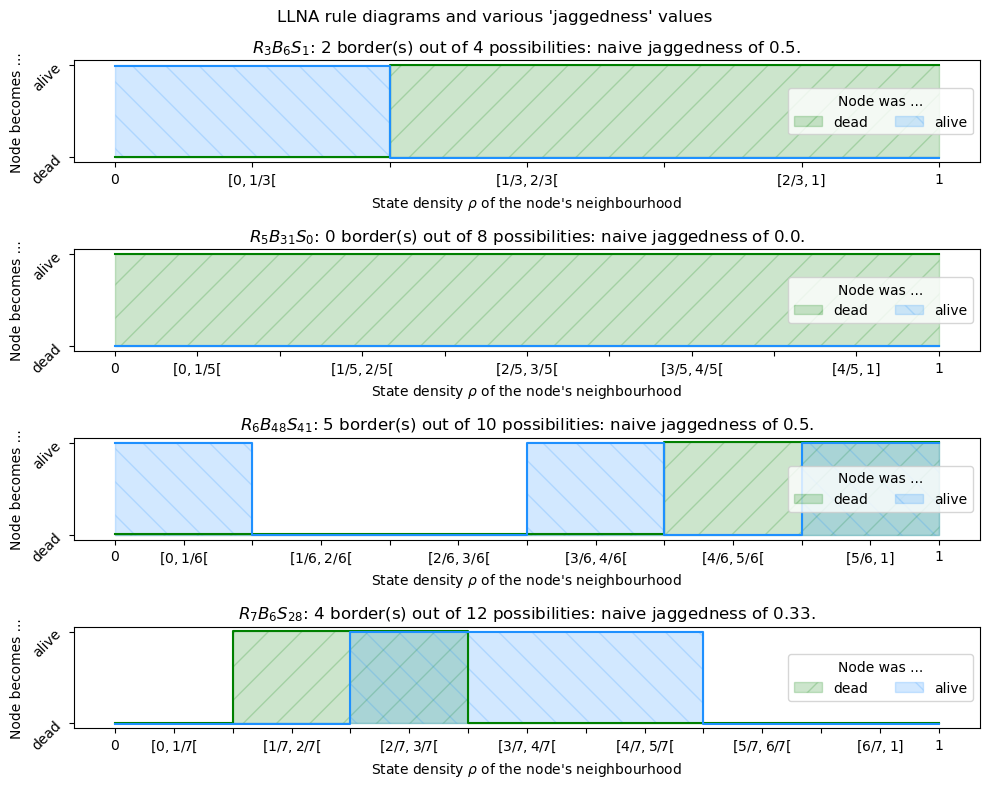

In [34]:
SAVEFIG=False

fig, axs = plt.subplots(4,1,figsize=(10, 8))

resolution = 3
born_if = [1, 2]
survive_if = [0]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[0])
j = naive_jaggedness(resolution, born_if, survive_if)
borders = j * 2*(resolution-1)
axs[0].set_title(f"{model.__str__(latex=True)}: {int(borders)} border(s) out of {2*(resolution-1)} possibilities: naive jaggedness of {round(j,2)}.")

resolution = 5
born_if = [0, 1, 2, 3, 4]
survive_if = []
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[1])
j = naive_jaggedness(resolution, born_if, survive_if)
borders = j * 2*(resolution-1)
axs[1].set_title(f"{model.__str__(latex=True)}: {int(borders)} border(s) out of {2*(resolution-1)} possibilities: naive jaggedness of {round(j,2)}.")

resolution = 6
born_if = [4, 5]
survive_if = [0, 3, 5]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[2])
j = naive_jaggedness(resolution, born_if, survive_if)
borders = j * 2*(resolution-1)
axs[2].set_title(f"{model.__str__(latex=True)}: {int(borders)} border(s) out of {2*(resolution-1)} possibilities: naive jaggedness of {round(j,2)}.")

resolution = 7
born_if = [1, 2]
survive_if = [2, 3, 4]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[3])
j = naive_jaggedness(resolution, born_if, survive_if)
borders = j * 2*(resolution-1)
axs[3].set_title(f"{model.__str__(latex=True)}: {int(borders)} border(s) out of {2*(resolution-1)} possibilities: naive jaggedness of {round(j,2)}.")

fig.suptitle("LLNA rule diagrams and various 'jaggedness' values")
fig.tight_layout()

Note:
1. We do not count the outer borders (those at $\rho = 0$ and $\rho = 1$) because they cannot be crossed.
2. The $B$ set has the same number of edges as the $B^\text{C}$ set, so the representation in the diagram does not matter.
3. There are always $2(R-1)$ possible borders.
4. There are more possibilities with an average number of borders than with a low or high number of borders.

## Add notion of changing the central node

If the central node is perturbed, the neighbourhood density is not altered, but the dynamical outcome may of course change as well. This is expressed by looking at some kind of XOR operation between the survive set and the born set. Again this value is normalised over the maximum (which is simply the resolution).

In [35]:
def naive_jaggedness_central_node(resolution, B_set, S_set):
    # make numpy array
    B_set = np.array(B_set)
    S_set = np.array(S_set)
    # turn interval index into bits
    B_set_bin = np.zeros(resolution, dtype=int)
    S_set_bin = np.zeros(resolution, dtype=int)
    if B_set.size: B_set_bin[B_set] = 1
    if S_set.size: S_set_bin[S_set] = 1
    borders = np.logical_xor(B_set_bin, S_set_bin).sum()
    return borders / resolution

In this spirit, the LLNA that can maximally change the outcome is the one that is the most jagged, and for which the born set is the complement of the survive set, for example

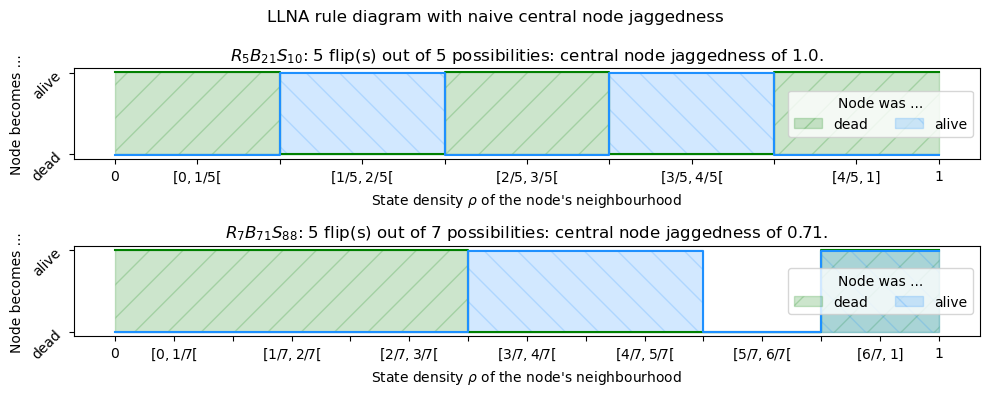

In [36]:
SAVEFIG=False

fig, axs = plt.subplots(2,1,figsize=(10, 4))

resolution = 5
born_if = [0, 2, 4]
survive_if = [1, 3]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[0])
j = naive_jaggedness_central_node(resolution, born_if, survive_if)
flips = int(j*resolution)
axs[0].set_title(f"{model.__str__(latex=True)}: {flips} flip(s) out of {resolution} possibilities: central node jaggedness of {round(j,2)}.")

resolution = 7
born_if = [0, 1, 2, 6]
survive_if = [3, 4, 6]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[1])
j = naive_jaggedness_central_node(resolution, born_if, survive_if)
flips = int(j*resolution)
axs[1].set_title(f"{model.__str__(latex=True)}: {flips} flip(s) out of {resolution} possibilities: central node jaggedness of {round(j,2)}.")

fig.suptitle("LLNA rule diagram with naive central node jaggedness")
fig.tight_layout()

It is not a priori clear how we should balance these two effects: the effect of changing the neighbourhood density, and the effect of changing the central node state. Some observations include:
1. Changing the state of the central node will always have the same effect; it is not depedent on the density of the local neighbourhood (and hence not dependent on the node degree)
2. LLNAs for which the 'central node jaggedness' is low and the 'naive jaggedness' is high, will generally not be very affected by introducing a defect. It is not clear, however, how important these definitions are compared to one another.
3. For isomorphic LLNAs, values from both jaggedness definitions are unchanged under an isomorphism

Also, a single jaggedness value is associated with a varying number of LLNAs. That is to say ...

_naive jaggedness definition_
- no borders: only one choice of border placement
- one border: $R-1$ choices
- two borders: $(R-1)(R-2)/2$ choices
- three borders: $(R-1)(R-2)(R-3)/6$ choices
- $N$ borders: $\prod_{i=1}^N(R-i)/i = \binom{R-1}{N}$ choices

Each of these border choices allows for two choices of intervals (either enabled or disabled). Summing all these possiblities, we find
$$
\left(2\sum_{N=0}^{R-1}\binom{R-1}{N}\right)^2 = \left(2 \times 2^{R-1}\right)^2 = 2^{2R},
$$
as required from the LLNA definition.

_central node jaggedness definition_
- zero central node jaggedness: all blocks must be identical: $2^R$ possible choices
- $1/R$ central node jaggedness: all-but-one blocks must be identical: $2^R R$ possible choices
- $2/R$ central node jaggedness: all-but-two blocks must be identical: $2^R R (R-1)/2$ possible choices
- $k/R$ central node jaggedness: all-but-$k$ blocks must be identical: $2^R R!/(R-k)!/k!$ possible choices

This again sums to a total of $2^{2R}$ choices, as required.

There does not seem to be an a priori reason to relate both jaggedness definitions. Let's inspect whether there is some correlation.

In [37]:
def base_repr_padded(integer, resolution):
    int_binary = np.base_repr(integer, base=2)
    int_binary = '0'*(resolution-len(int_binary)) + int_binary
    return int_binary

# TODO there is definitely a nicer way to do this! That's not really the point here though
def int_to_set(integer, resolution):
    if integer >= 2**resolution:
        raise Exception(f"The value of the integer encoding the density intervals should not exceed {2**resolution-1}.")
    intervals = list(range(resolution))
    density_set = []
    brp = base_repr_padded(integer, resolution)
    for i, char in enumerate(brp[::-1]):
        if char=='1':
            density_set.append(i)
    return np.array(density_set)

Check whether the values of the naive jaggedness and the central-node jaggedness are independent, as they should be.

In [38]:
resolution = 8 # the higher, the (exponentially) more time it takes to calculate
B_sets = [int_to_set(integer, resolution) for integer in range(2**resolution)]
S_sets = B_sets.copy()

naive_js = []
naive_js_cn = []
for B_set in B_sets:
    for S_set in S_sets:
        naive_js += [naive_jaggedness(resolution, B_set, S_set)]
        naive_js_cn += [naive_jaggedness_central_node(resolution, B_set, S_set)]

# the values are independent of each other, indeed!
from scipy.stats import pearsonr
pr = pearsonr(naive_js, naive_js_cn).statistic

print(f"The Pearson's R is {pr}. There is no correlation.")

The Pearson's R is 0.0. There is no correlation.


Now let us see how the values of the jaggedness can be grouped, based on the size of the sets.

In [8]:
import itertools

# sets to choose from (two sets are identical)
resolution = 7
R_set = np.arange(resolution)

# Collect all valid combinations of two sets
j_values_per_total_size = []
j_values_cn_per_total_size = []
total_sizes = range(2*resolution+1)
for total_size in total_sizes:
    j_values = []
    j_values_cn = []
    for k in range(total_size + 1):  # k = number of elements from set1
        if k <= resolution and total_size - k <= resolution:
            # Combinations from set of density intervals
            B_sets = list(itertools.combinations(R_set, k))
            S_sets = list(itertools.combinations(R_set, total_size - k))
            # iterate over combinations of both sets that sum to total_size
            for B_set in B_sets:
                for S_set in S_sets:
                    j_value = naive_jaggedness(resolution, B_set, S_set)
                    j_value_cn = naive_jaggedness_central_node(resolution, B_set, S_set)
                    j_values.append(j_value)
                    j_values_cn.append(j_value_cn)
    j_values_per_total_size.append(j_values)
    j_values_cn_per_total_size.append(j_values_cn)

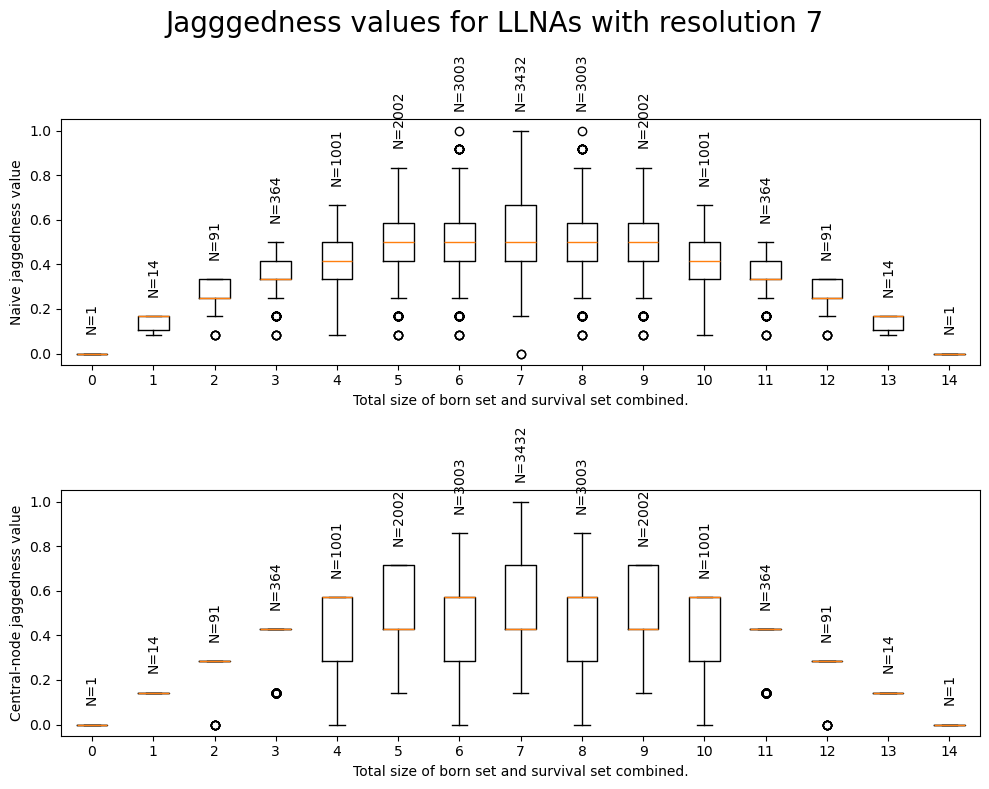

In [9]:
fig, axs = plt.subplots(2,1,figsize=(10,8), sharex=False)
axs[0].boxplot(j_values_per_total_size, tick_labels=total_sizes)
axs[1].boxplot(j_values_cn_per_total_size, tick_labels=total_sizes)
for ax in axs:
    ax.set_xlabel(f"Total size of born set and survival set combined.")
axs[0].set_ylabel("Naive jaggedness value")
axs[1].set_ylabel("Central-node jaggedness value")

# Annotate with the number of data points
for i, (dataset1, dataset2) in enumerate(zip(j_values_per_total_size, j_values_cn_per_total_size)):
    n1 = len(dataset1)  # Number of data points
    n2 = len(dataset2)
    axs[0].text(i + 1, max(dataset1) + 0.1, f'N={n1}', ha='center', fontsize=10, rotation=90)
    axs[1].text(i + 1, max(dataset2) + 0.1, f'N={n2}', ha='center', fontsize=10, rotation=90)

fig.suptitle(f"Jagggedness values for LLNAs with resolution {resolution}", size=20)
fig.tight_layout()

In [10]:
# TODO: add a grid with size vs size with colours indicating the average jaggedness.

# Define parameters
resolution = 11
R_set = np.arange(resolution)

B_sizes = range(resolution + 1)
S_sizes = range(resolution + 1)

# Precompute all combinations for given sizes
combinations_by_size = {size: list(itertools.combinations(R_set, size)) for size in range(resolution + 1)}

# Initialize grids for results
j_values_mean_grid = np.zeros((resolution + 1, resolution + 1))
j_values_cn_mean_grid = np.zeros((resolution + 1, resolution + 1))

# Compute mean jaggedness values
for B_size in B_sizes:
    print(f"Working on B_size {B_size}/{resolution}.    ", end='\r')
    B_sets = combinations_by_size[B_size]
    for S_size in S_sizes:
        S_sets = combinations_by_size[S_size]
        # Compute jaggedness values for all combinations
        j_values = [
            naive_jaggedness(resolution, B_set, S_set)
            for B_set in B_sets for S_set in S_sets
        ]
        j_values_cn = [
            naive_jaggedness_central_node(resolution, B_set, S_set)
            for B_set in B_sets for S_set in S_sets
        ]
        # Store means in grids
        j_values_mean_grid[B_size, S_size] = np.mean(j_values)
        j_values_cn_mean_grid[B_size, S_size] = np.mean(j_values_cn)


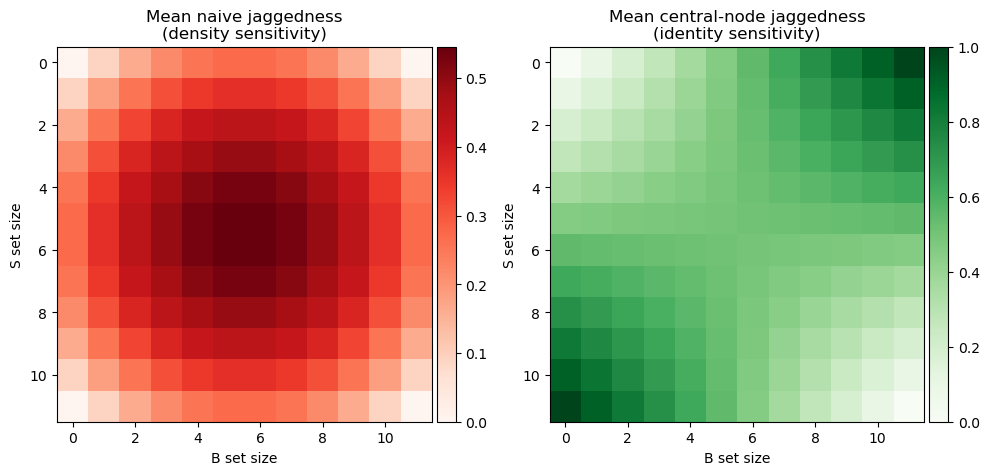

In [11]:
fig, axs = plt.subplots(1,2,figsize=(10, 5))

im0 = axs[0].imshow(j_values_mean_grid, cmap='Reds')
im1 = axs[1].imshow(j_values_cn_mean_grid, cmap='Greens')

for ax in axs:
    ax.set_xlabel("B set size")
    ax.set_ylabel("S set size")
axs[0].set_title("Mean naive jaggedness\n(density sensitivity)")
axs[1].set_title("Mean central-node jaggedness\n(identity sensitivity)")

# Create a colorbar that aligns perfectly
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create an axis for the colorbar
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust size and padding
cbar = plt.colorbar(im0, cax=cax)  # Use the new axis for the colorbar
# Same for the second one
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust size and padding
cbar = plt.colorbar(im1, cax=cax)  # Use the new axis for the colorbar


fig.tight_layout()

Interestingly, these values seem to convey very different information! Also note that the observed symmetry corresponds with imposed isomorphisms.

The above discussion shows the distribution of the values simply as a result of combinatorics. A complete and useful definition of jaggedness should probably take into account these combinatorial aspects, allowing for some kind of normalisation.

## Add weighing over degree distribution

Different levels of weighing:
1. Take into account the average node degree
2. Perform a weighted sum over all node degrees
3. Take into account that some densities are more common than others
4. Take into account that the density distribution changes over time
5. Take into account that more than one cell can change state at the same time (so neighbourhood density of node $i$ changes more than $d_i^{-1}$)

## Weighing the naive jaggedness by average node degree

The current definition of the jaggedness (horizontal sensitivity) presupposes that a change in density always causes the density to shift one "block to the side". This is of course generally not true at all: even for regular networks, this 'horizontal movement' can be small (remain in the density interval) or large (skip one or more density intervals).

Rather than counting the number of edges, we want to count whether a particular change in density would cause the output of the local update function to change. This is is some kind of Boolean derivative, as we would calculate by means of the Jacobian, but it does not directly take into account the network structure or the particular configuration. It is therefore easier to calculate, but may already contain a lot of interesting information on the network automaton.

**Question** how do we count the edge cases? When all nodes are in state $0$, the only flip can be $0 \mapsto 1$. However, in a more diverse configuration, the flip can go both ways. How is this counted in the definition of the density sensitivity?

Now we need some basic information of the graph, so we load the graph package.

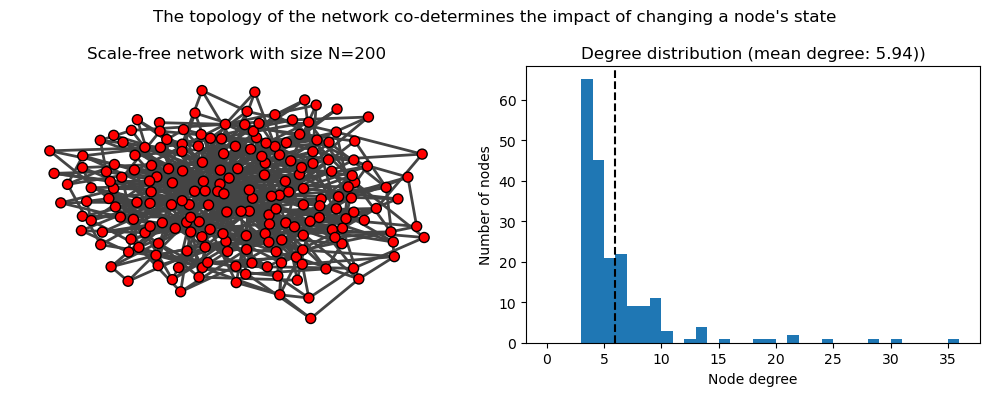

In [2]:
import igraph as ig

# a simple network
N = 200
min_edges = 3
G = ig.Graph.Barabasi(N, min_edges)

# find edges
G.to_directed()
edges = tc.tensor(G.get_edgelist()).T
G.to_undirected()

fig, axs = plt.subplots(1,2,figsize=(10,4))

vertex_size=10
ig.plot(G, target=axs[0], vertex_size=vertex_size)
axs[0].set_title(f"Scale-free network with size N={N}")

degrees = G.degree()
degree_mean=np.mean(degrees)
degree_max=max(degrees)
axs[1].hist(degrees, bins=range(degree_max))
axs[1].axvline(degree_mean, color='k', ls='--')
axs[1].set_title(f"Degree distribution (mean degree: {round(degree_mean,2)}))")
axs[1].set_xlabel("Node degree")
axs[1].set_ylabel("Number of nodes")

fig.suptitle("The topology of the network co-determines the impact of changing a node's state")
fig.tight_layout()

# TODO: add expected mean degree

In [3]:
from itertools import chain, combinations

def all_subsets(R):
    # Generate all subsets of range(R) where R is the resolution.
    # NOTE: there are certainly more efficient ways of doing this, but it's fine for now
    return list(chain.from_iterable(combinations(range(R), r) for r in range(R + 1)))

R = 3  # Example value for N
all_possible_subsets = all_subsets(R)
random_subset = all_possible_subsets[np.random.randint(2**R)]

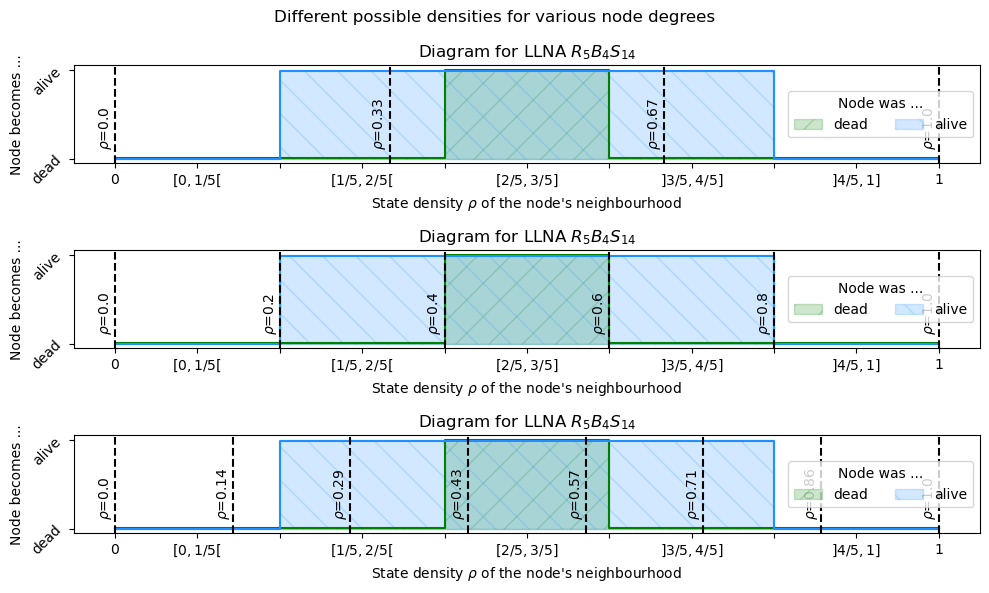

In [5]:
resolution = 5
# take random samples
all_possible_subsets = all_subsets(resolution)
born_if = all_possible_subsets[np.random.randint(2**resolution)]
survive_if = all_possible_subsets[np.random.randint(2**resolution)]

# assign rules and generate LLNA
# NOTE: this should be the same as just not filling in x and y)
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

fig, axs = plt.subplots(3,1,figsize=(10,6))

for ax, d in zip(axs, [3, 5, 7]):
    model.diagram(ax=ax)
    for rho in np.linspace(0, 1, d+1):
        ax.axvline(rho,  color='k', ls='--')
        ax.text(rho-.022, .15, fr"$\rho$={round(rho,2)}", rotation=90)

fig.suptitle(f"Different possible densities for various node degrees")
fig.tight_layout()

Now let's think this through for a particular value of degree $d$. Say, for simplicity, that the degree is $d=3$.
- The possible densities around a particular node are $\rho \in \{0, \frac{1}{3}, \frac{2}{3}, 1\}$.
- In case the density is $0$, introducing a defect means that the density will go to $\frac{1}{3}$ with a probability of $1$.
- In case the density is $1$, introducing a defect means that the density will go to $\frac{2}{3}$ with a probability of $1$.
- In case the density is $\frac{1}{3}$, introducing a defect means that the density will go to $0$ with a probability of $\frac{1}{3}$, and to $\frac{2}{3}$ with a probability of $1-\frac{1}{3} = \frac{2}{3}$.
- In case the density is $\frac{2}{3}$, introducing a defect means that the density will go to $\frac{1}{3}$ with a probability of $\frac{2}{3}$, and to $1$ with a probability of $1-\frac{2}{3} = \frac{1}{3}$.

Each of these densities occurs with a different probability. Just looking at $d$ nodes, there are $\dfrac{d!}{k!(d-k)!} = \dbinom{d}{k}$ of marking $k$ alive nodes.

In the case of a fully-connected network with a random configuration, these probabilities remain the same. However
- our networks are not fully-connected
- the densities change dynamically. They do so differently for distinct node degrees.

In [6]:
from scipy.special import comb
def density_sensitivities_per_degree(degree, model):
    """
    Answers the question: given an particular update rule and a particular node degree:
    >> What is the probability that the response will change, when a random neigbhourhood node is flipped? <<
    """
    # define all possible densities
    rhos = tc.Tensor(tc.arange(0, degree+1)/degree)

    # define the associated probabilities, assuming maximal randomness.
    # NOTE: in a later stage, this can be fed to the function (when randomness is not assumed)
    rho_probs = tc.Tensor([comb(degree, k)/2.**degree for k in range(degree+1)])#.unsqueeze(0)
    # make sure it sums to 1, as a probability should
    rho_probs /= rho_probs.sum()

    # define the one-hot interval encoding associated with the densitities for this degree
    int_enc = model.interval_encoding(rhos.unsqueeze(0))[0]

    # find which densities are in an active interval
    rhos_in_active_int_x = (int_enc * model._x.T).sum(1)
    rhos_in_active_int_y = (int_enc * model._y.T).sum(1)

    # find whether slightly changing the density causes a different update response
    # from minimum density (can only defect "off" nodes)
    from_min_dens_x = (rhos_in_active_int_x[0]!=rhos_in_active_int_x[1]).float().unsqueeze(0)
    from_min_dens_y = (rhos_in_active_int_y[0]!=rhos_in_active_int_y[1]).float().unsqueeze(0)
    # from maximum density (can only defect "on" nodes)
    from_max_dens_x = (rhos_in_active_int_x[-2]!=rhos_in_active_int_x[-1]).float().unsqueeze(0)
    from_max_dens_y = (rhos_in_active_int_y[-2]!=rhos_in_active_int_y[-1]).float().unsqueeze(0)
    # from non-extremum density, shift to lower density, multiplied with probability of defecting an "on" node
    shift_left_dens_x = (rhos_in_active_int_x[1:-1] != rhos_in_active_int_x[:-2]).float()
    shift_left_dens_x *= rhos[1:-1]
    shift_left_dens_y = (rhos_in_active_int_y[1:-1] != rhos_in_active_int_y[:-2]).float()
    shift_left_dens_y *= rhos[1:-1]
    # from non-extremum density, shift to higher density, multiplied with probability of defecting an "off" node
    shift_right_dens_x = (rhos_in_active_int_x[1:-1] != rhos_in_active_int_x[2:]).float()
    shift_right_dens_x *= 1-rhos[1:-1]
    shift_right_dens_y = (rhos_in_active_int_y[1:-1] != rhos_in_active_int_y[2:]).float()
    shift_right_dens_y *= 1-rhos[1:-1]
    # add all non-extremum density shifts
    from_middle_dens_x = shift_left_dens_x + shift_right_dens_x
    from_middle_dens_y = shift_left_dens_y + shift_right_dens_y
    # concatenate with extremum density shifts
    from_any_dens_x = tc.cat((from_min_dens_x, from_middle_dens_x, from_max_dens_x))
    from_any_dens_y = tc.cat((from_min_dens_y, from_middle_dens_y, from_max_dens_y))

    # multiply with the probability of starting from a particular density in the first place
    prob_of_response_change_x = (rho_probs * from_any_dens_x).sum().item()
    prob_of_response_change_y = (rho_probs * from_any_dens_y).sum().item()

    return prob_of_response_change_x, prob_of_response_change_y

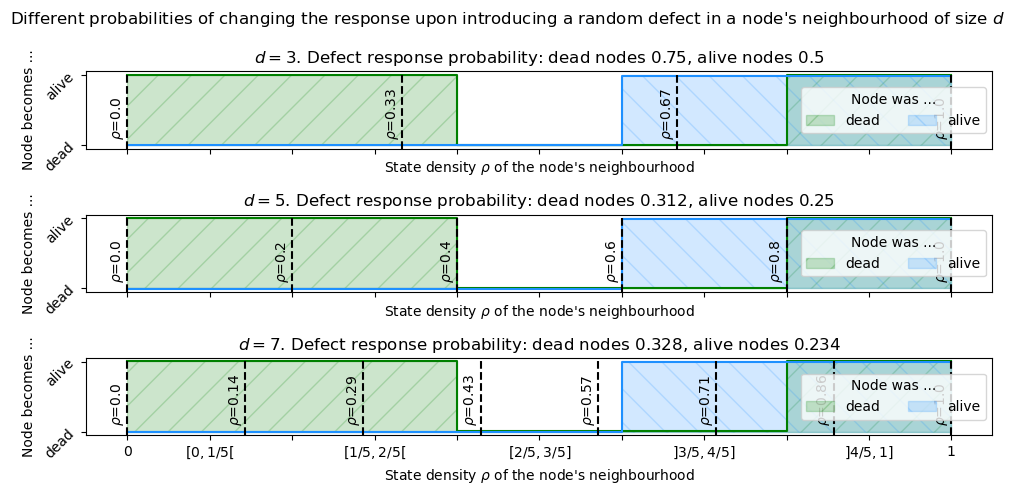

In [7]:
# verify for some obvious cases: minimum

resolution = 5
born_if = [0, 1, 4]# range(resolution)
survive_if = [3, 4]# range(resolution)

# assign rules and generate LLNA
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

fig, axs = plt.subplots(3,1,figsize=(10,5), sharex=True)

for ax, d in zip(axs, [3, 5, 7]):
    model.diagram(ax=ax)
    for rho in np.linspace(0, 1, d+1):
        ax.axvline(rho,  color='k', ls='--')
        ax.text(rho-.022, .15, fr"$\rho$={round(rho,2)}", rotation=90)
        B_set_prob, S_set_prob = density_sensitivities_per_degree(d, model)
        ax.set_title(fr"$d={d}$. Defect response probability: dead nodes {round(B_set_prob,3)}, alive nodes {round(S_set_prob,3)}")

fig.suptitle(fr"Different probabilities of changing the response upon introducing a random defect in a node's neighbourhood of size $d$")
fig.tight_layout()

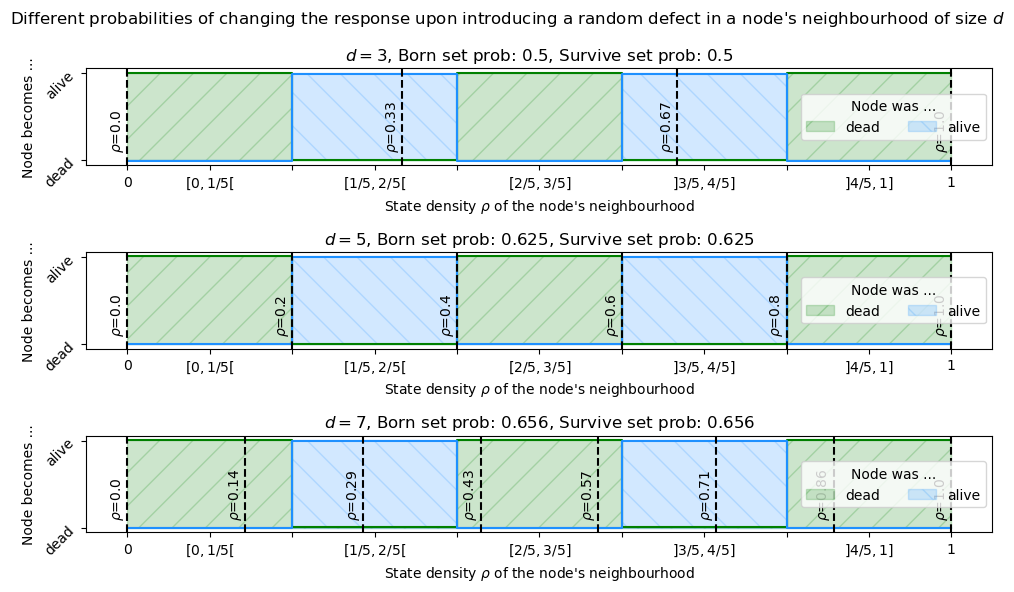

In [8]:
# verify for some obvious cases: minimum

resolution = 5
born_if = [0,2,4]
survive_if = [1,3]

# assign rules and generate LLNA
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

fig, axs = plt.subplots(3,1,figsize=(10,6))

for ax, d in zip(axs, [3, 5, 7]):
    model.diagram(ax=ax)
    for rho in np.linspace(0, 1, d+1):
        ax.axvline(rho,  color='k', ls='--')
        ax.text(rho-.022, .15, fr"$\rho$={round(rho,2)}", rotation=90)
        B_set_prob, S_set_prob = density_sensitivities_per_degree(d, model)
        ax.set_title(fr"$d={d}$, Born set prob: {round(B_set_prob,3)}, Survive set prob: {round(S_set_prob,3)}")

fig.suptitle(fr"Different probabilities of changing the response upon introducing a random defect in a node's neighbourhood of size $d$")
fig.tight_layout()

Text(0.5, 1.0, 'LLNA $R_{5}B_{21}S_{10}$')

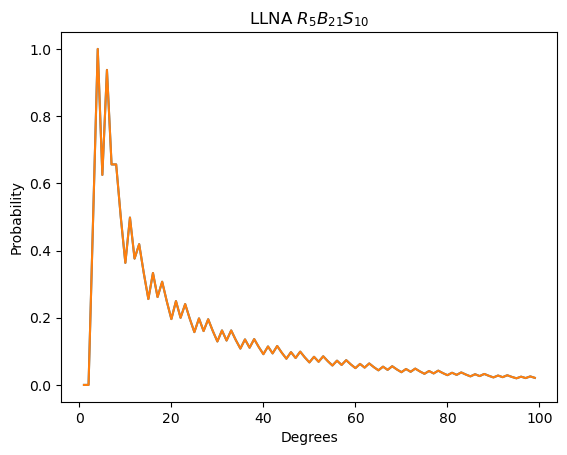

In [9]:
degrees = np.arange(1,100)
dens_sens_probs = [density_sensitivities_per_degree(degree, model) for degree in degrees]

plt.plot(degrees, dens_sens_probs)
plt.xlabel("Degrees")
plt.ylabel("Probability")
plt.title(f"LLNA {model.__str__(latex=True)}")

In [10]:
def density_sensitivity_v1(degrees, model):
    """
    TODO: this sometimes outputs a nan, probably because of very low probabilities
    Answers the question: 'what is the probability that a randomly chosen node will change its update schedule if one random node in its neighbourhood changes its current state?'
    We assume that all nodes are randomly assigned and that the network is big
    """
    # find all unique degrees and how many times they occur
    unique_degrees, counts = np.unique(degrees, return_counts=True)
    # sum over every degree and average the probabilities accordingly
    total_change_prob = 0
    for unique_degree, count in zip(unique_degrees, counts):
        # use earlier definition
        born_change_prob, survive_change_prob = density_sensitivities_per_degree(unique_degree, model)
        # weight over possible changes and number of counts in the network
        born_change_prob = born_change_prob * count
        survive_change_prob = survive_change_prob * count
        # make an (unweighed) average of the born_changes and survive changes, assuming random assignment
        prob_of_node_dead = .5
        prob_of_node_alive = 1-prob_of_node_dead
        change_prob = prob_of_node_dead*born_change_prob + prob_of_node_alive*survive_change_prob
        total_change_prob += change_prob
    # number of nodes
    N=len(degrees)
    total_change_prob = total_change_prob / N
    return total_change_prob

degrees = np.arange(1,30)
density_sensitivity_v1(degrees, model)

0.3525963107059742

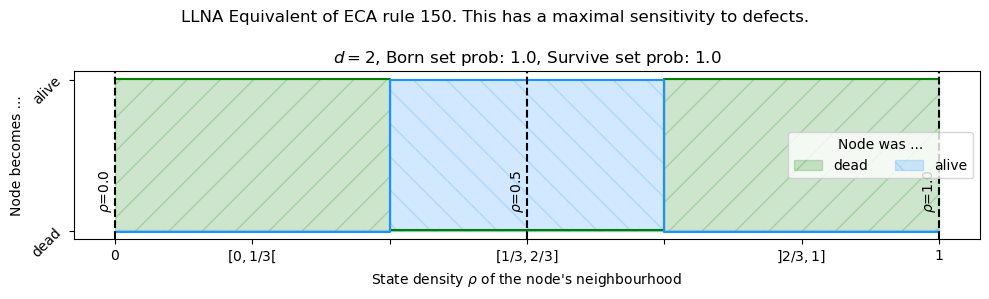

In [11]:
# verify for some obvious cases: minimum

resolution = 3
born_if = [0,2]
survive_if = [1]

# assign rules and generate LLNA
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

fig, ax = plt.subplots(1,1,figsize=(10,3))

d = 2
model.diagram(ax=ax)
for rho in np.linspace(0, 1, d+1):
    ax.axvline(rho,  color='k', ls='--')
    ax.text(rho-.022, .15, fr"$\rho$={round(rho,2)}", rotation=90)
    B_set_prob, S_set_prob = density_sensitivities_per_degree(d, model)
    ax.set_title(fr"$d={d}$, Born set prob: {round(B_set_prob,3)}, Survive set prob: {round(S_set_prob,3)}")

fig.suptitle(fr"LLNA Equivalent of ECA rule 150. This has a maximal sensitivity to defects.")
fig.tight_layout()

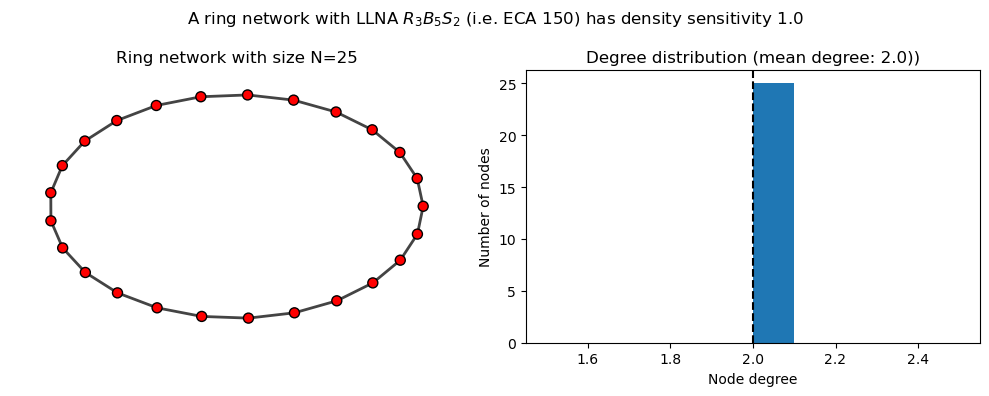

In [12]:
N = 25
G = ig.Graph.Ring(N)

# find edges
G.to_directed()
edges = tc.tensor(G.get_edgelist()).T
G.to_undirected()

fig, axs = plt.subplots(1,2,figsize=(10,4))

vertex_size=10
ig.plot(G, target=axs[0], vertex_size=vertex_size)
axs[0].set_title(f"Ring network with size N={N}")

degrees = G.degree()
degree_mean=np.mean(degrees)
degree_max=max(degrees)
axs[1].hist(degrees)
axs[1].axvline(degree_mean, color='k', ls='--')
axs[1].set_title(f"Degree distribution (mean degree: {round(degree_mean,2)}))")
axs[1].set_xlabel("Node degree")
axs[1].set_ylabel("Number of nodes")

dens_sens = density_sensitivity_v1(degrees, model)
fig.suptitle(fr"A ring network with LLNA {model.__str__(latex=True)} (i.e. ECA $150$) has density sensitivity {dens_sens}")
fig.tight_layout()

Below we inspect the relationship between the 'naive jaggedness' and the degree-weighed density sensitivity for a single network and for all possible LLNA.

If this correlation is very high, we can simply use the naive jaggedness for future reference (as this is much easier to compute).

In [18]:
# a simple scale-free network
N = 200
min_edges = 3
G = ig.Graph.Barabasi(N, min_edges)
degrees = list(G.degree())

resolution = 5 # don't take this too high. 7 already takes ten minutes
B_sets = all_subsets(resolution)
S_sets = all_subsets(resolution)

# run over all possible combinations of Born and Survive sets
naive_js = [naive_jaggedness(resolution, B_set, S_set) for B_set in tqdm(B_sets, total=2**resolution) for S_set in S_sets]
dens_senses = [density_sensitivity_v1(degrees, LLNA(resolution, x=B_set, y=S_set, iso=True)) for B_set in tqdm(B_sets, total=2**resolution) for S_set in S_sets]

100%|██████████| 32/32 [00:37<00:00,  1.16s/it]


Text(0.5, 1.0, 'Correlation of two robustness measures. $N=200$, $R=5$.')

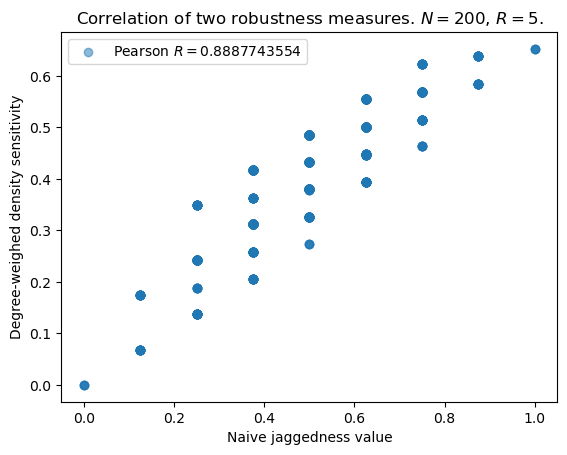

In [19]:
# the values are independent of each other, indeed!
from scipy.stats import pearsonr
pr = pearsonr(naive_js, dens_senses).statistic

plt.scatter(naive_js, dens_senses, alpha=.5, label=fr"Pearson $R={round(pr,10)}$")
plt.legend(loc='upper left')
plt.xlabel("Naive jaggedness value")
plt.ylabel("Degree-weighed density sensitivity")
plt.title(fr"Correlation of two robustness measures. $N={N}$, $R={resolution}$.")

# plt.savefig(f"scale-free_res{R}_N{N}_correlation-naive-vs-weighed.pdf", bbox_inches='tight')
# TODO: colour-code this according to the size of the update sets

For low resolution, there is an exact correlation. Is this expected?
For higher resolution, there is quite some correlation, but it's not trivial at all! Can this pattern be explained?

  0%|          | 0/6 [00:00<?, ?it/s]


KeyboardInterrupt: 

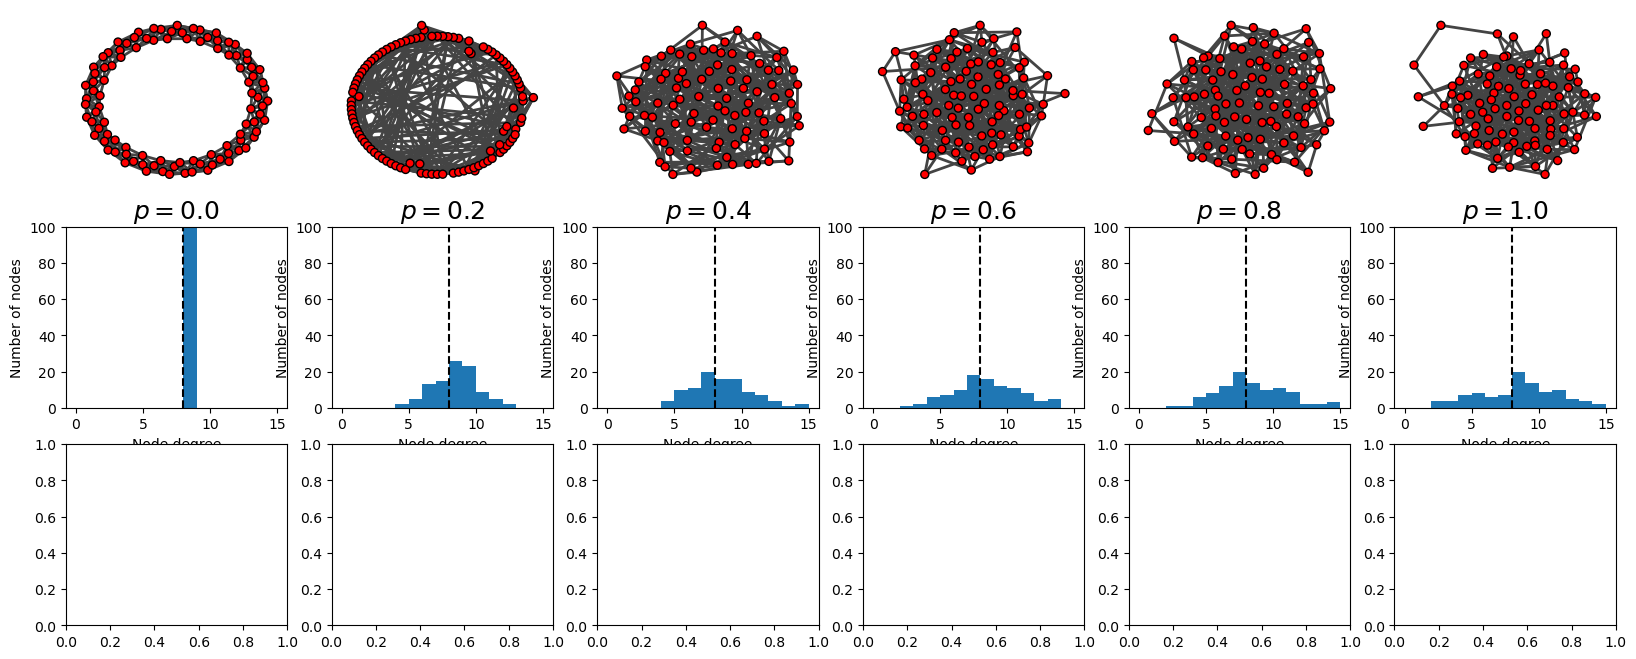

In [211]:
# find link between update set size and this particular sensitivity definition

### GET NETWORK

# a simple network
N = 100
# min_edges = 3
# G = ig.Graph.Barabasi(N, min_edges)
# G = ig.Graph.Erdos_Renyi(N, .1)

# takes a long time for high resolution
resolution = 3 # res 7 takes half an hour

# Parameters for the Watts-Strogatz model
k = 8      # Each node is connected to k nearest neighbors
ps = np.linspace(0,1,6)
total = len(ps)
Gs = []
degrees_per_p = []
dens_senses = []
max_degree = 0
for p in ps:
    G = ig.Graph.Watts_Strogatz(dim=1, size=N, nei=k//2, p=p)
    # make new iterations until a connected network is found
    iterator = 0
    while not G.is_connected():
        iterator += 1
        if iterator == 100: raise Exception("Connected network cannot be created")
        G = ig.Graph.Watts_Strogatz(dim=1, size=N, nei=k//2, p=p)
    Gs.append(G)
    degrees = G.degree()
    current_max_degree = max(degrees)
    if current_max_degree > max_degree:
        max_degree = current_max_degree
    degrees_per_p.append(degrees)

fig, axs = plt.subplots(3,total,figsize=(20,8))

# plot graphs
for G, ax in tqdm(zip(Gs, axs[0]), total=total):
    vertex_size=8
    ig.plot(G, target=ax, vertex_size=vertex_size)
    
# plot degree distributions
for degrees, p, ax in tqdm(zip(degrees_per_p, ps, axs[1]), total=total):
    degree_mean=np.mean(degrees)
    ax.hist(degrees, bins=range(max_degree))
    ax.set_ylim(0,N)
    ax.axvline(degree_mean, color='k', ls='--')
    ax.set_title(fr"$p={round(p,2)}$", size=18)
    ax.set_xlabel("Node degree")
    ax.set_ylabel("Number of nodes")
# plot correlations of two measures

B_sets = all_subsets(resolution)
S_sets = all_subsets(resolution)
from scipy.stats import pearsonr
for degrees, ax in tqdm(zip(degrees_per_p, axs[2]), total=total):
    naive_js = [naive_jaggedness(resolution, B_set, S_set) for B_set in B_sets for S_set in S_sets]
    dens_senses = [density_sensitivity_v1(degrees, LLNA(resolution, x=B_set, y=S_set, iso=True)) for B_set in B_sets for S_set in S_sets]
    pr = pearsonr(naive_js, dens_senses).statistic
    # plot
    ax.scatter(naive_js, dens_senses, alpha=.5, label=fr"Pearson $R={round(pr,2)}$")
    ax.set_xlim([-0.05,1.05])
    ax.set_ylim([-0.05,1.05])
    ax.legend(loc='upper left')
    # ax.set_xlabel("Naive jaggedness value")
    # ax.set_ylabel("Degree-weighed density sensitivity")
    ax.set_title(fr"Max: $R={round(max(dens_senses),2)}$", size=18)

fig.suptitle(fr"Correlation between two robustness measures for all $R={resolution}$ rules on $N={N}$ WS networks", size=28)
fig.tight_layout()

plt.savefig(f"change-my-name.pdf", bbox_inches='tight')

In [30]:
np.count(degrees)

AttributeError: module 'numpy' has no attribute 'count'

Let's do the same for various scale-free networks with different parameters

100%|██████████| 6/6 [00:08<00:00,  1.44s/it]


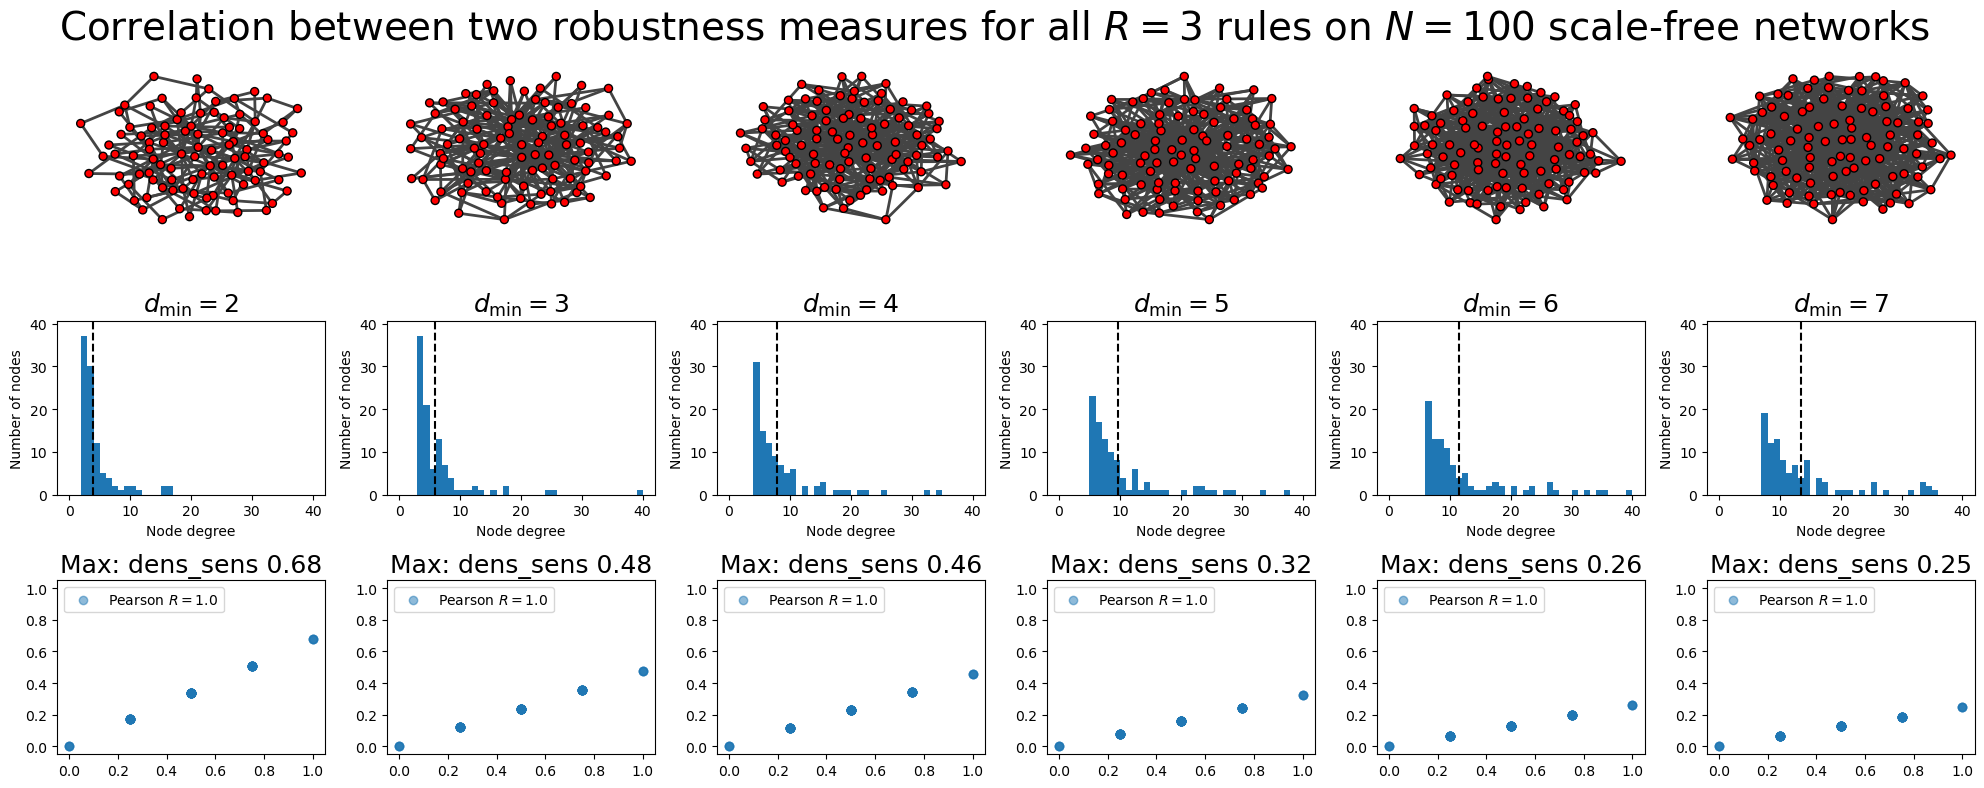

In [31]:
# find link between update set size and this particular sensitivity definition

### GET NETWORK

# a simple network
N = 100
# min_edges = 3
# G = ig.Graph.Barabasi(N, min_edges)
# G = ig.Graph.Erdos_Renyi(N, .1)

# takes a long time for high resolution
resolution = 3 # res 7 takes half an hour

# Parameters for the Watts-Strogatz model
min_edges_list = [2, 3, 4, 5, 6, 7]
total = len(min_edges_list)
Gs = []
degrees_per_min_edges = []
dens_senses = []
max_degree = 0
max_count = 0
for min_edges in min_edges_list:
    G = ig.Graph.Barabasi(N, min_edges)
    # make new iterations until a connected network is found
    iterator = 0
    while not G.is_connected():
        iterator += 1
        if iterator == 100: raise Exception("Connected network cannot be created")
        G = ig.Graph.Barabasi(N, min_edges)
    Gs.append(G)
    degrees = G.degree()
    current_max_degree = max(degrees)
    if current_max_degree > max_degree:
        max_degree = current_max_degree
    current_max_count = np.unique(degrees, return_counts=True)[1].max()
    if current_max_count > max_count:
        max_count = current_max_count
    degrees_per_min_edges.append(degrees)

fig, axs = plt.subplots(3,total,figsize=(20,8))

# plot graphs
for G, ax in tqdm(zip(Gs, axs[0]), total=total):
    vertex_size=8
    ig.plot(G, target=ax, vertex_size=vertex_size)
    
# plot degree distributions
for degrees, min_edges, ax in tqdm(zip(degrees_per_min_edges, min_edges_list, axs[1]), total=total):
    degree_mean=np.mean(degrees)
    ax.hist(degrees, bins=range(max_degree))
    ax.set_ylim(0,max_count*1.1)
    ax.axvline(degree_mean, color='k', ls='--')
    ax.set_title(fr"$d_\text{{min}}={min_edges}$", size=18)
    ax.set_xlabel("Node degree")
    ax.set_ylabel("Number of nodes")

# plot correlations of two measures

B_sets = all_subsets(resolution)
S_sets = all_subsets(resolution)
from scipy.stats import pearsonr
for degrees, ax in tqdm(zip(degrees_per_min_edges, axs[2]), total=total):
    naive_js = [naive_jaggedness(resolution, B_set, S_set) for B_set in B_sets for S_set in S_sets]
    dens_senses = [density_sensitivity_v1(degrees, LLNA(resolution, x=B_set, y=S_set, iso=True)) for B_set in B_sets for S_set in S_sets]
    pr = pearsonr(naive_js, dens_senses).statistic
    # plot
    ax.scatter(naive_js, dens_senses, alpha=.5, label=fr"Pearson $R={round(pr,2)}$")
    ax.set_xlim([-0.05,1.05])
    ax.set_ylim([-0.05,1.05])
    ax.legend(loc='upper left')
    # ax.set_xlabel("Naive jaggedness value")
    # ax.set_ylabel("Degree-weighed density sensitivity")
    ax.set_title(fr"Max: dens_sens {round(max(dens_senses),2)}", size=18)

fig.suptitle(fr"Correlation between two robustness measures for all $R={resolution}$ rules on $N={N}$ scale-free networks", size=28)
fig.tight_layout()

# plt.savefig(f"change-my-name.pdf", bbox_inches='tight')

In [ ]:
# find link between WS rewiring param and 

# a simple network
N = 100
# min_edges = 3
# G = ig.Graph.Barabasi(N, min_edges)
# G = ig.Graph.Erdos_Renyi(N, .1)

model = LLNA(resolution=7)

# Parameters for the Watts-Strogatz model
k = 8      # Each node is connected to k nearest neighbors
ps = np.linspace(0,.5,6)
Gs = []
degrees_per_p = []
dens_senses = []
max_degree = 0
for p in ps:
    G = ig.Graph.Watts_Strogatz(dim=1, size=N, nei=k//2, p=p)
    # make new iterations until a connected network is found
    iterator = 0
    while not G.is_connected():
        iterator += 1
        if iterator == 100: raise Exception("Connected network cannot be created")
        G = ig.Graph.Watts_Strogatz(dim=1, size=N, nei=k//2, p=p)
    Gs.append(G)
    degrees = G.degree()
    current_max_degree = max(degrees)
    if current_max_degree > max_degree:
        max_degree = current_max_degree
    degrees_per_p.append(degrees)
    dens_sens = density_sensitivity_v1(degrees, model)
    dens_senses.append(dens_sens)

fig, (axs_up, axs_down) = plt.subplots(2,len(ps),figsize=(20,5))

for G, ax in zip(Gs, axs_up):
    vertex_size=8
    ig.plot(G, target=ax, vertex_size=vertex_size)
for degrees, p, dens_sens, ax in zip(degrees_per_p, ps, dens_senses, axs_down):
    degree_mean=np.mean(degrees)
    ax.hist(degrees, bins=range(max_degree))
    ax.set_ylim(0,N)
    ax.axvline(degree_mean, color='k', ls='--')
    ax.set_title(fr"$p={round(p,2)}$, prob={round(dens_sens,2)}")
    ax.set_xlabel("Node degree")
    ax.set_ylabel("Number of nodes")

fig.tight_layout()

'R5B31S31'

In [102]:
# TODO: iteratively making the LLNA model takes up quite some time. That's not ideal.

# GET GRID OF DENS SENS VALUES

import itertools

# Define parameters
resolution = 5
R_set = np.arange(resolution)

B_sizes = range(resolution + 1)
S_sizes = range(resolution + 1)

# Precompute all combinations for given sizes
combinations_by_size = {size: list(itertools.combinations(R_set, size)) for size in range(resolution + 1)}

# Initialize grids for results
ds_values_mean_grid = np.zeros((resolution + 1, resolution + 1))

# Compute mean density sensitivity values
for B_size in B_sizes:
    print(f"Working on B_size {B_size}/{resolution}.    ", end='\r')
    B_sets = combinations_by_size[B_size]
    for S_size in S_sizes:
        S_sets = combinations_by_size[S_size]
        # Compute jaggedness values for all combinations
        ds_values=[]
        for B_set in B_sets:
            for S_set in S_sets:
                model = LLNA(resolution, x=B_set, y=S_set)
                ds_value = density_sensitivity_v1(degrees, model)
                ds_values.append(ds_value)
        # Store means in grids
        ds_values_mean_grid[B_size, S_size] = np.mean(ds_values)

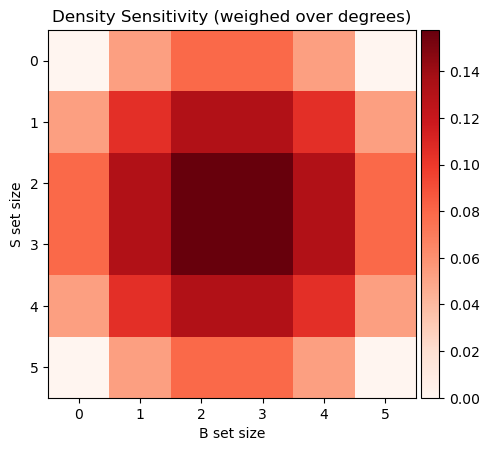

In [103]:
fig, ax = plt.subplots(1,1,figsize=(5, 5))

im0 = ax.imshow(ds_values_mean_grid, cmap='Reds')


ax.set_xlabel("B set size")
ax.set_ylabel("S set size")
ax.set_title("Density Sensitivity (weighed over degrees)")

# Create a colorbar that aligns perfectly
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create an axis for the colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust size and padding
cbar = plt.colorbar(im0, cax=cax)  # Use the new axis for the colorbar

fig.tight_layout()

This looks A LOT like the naive one. That's perhaps not unexpected, because the probability of altered outcome is strongly dominated by low-degree nodes, and a scale-free network has mostly low-degree nodes. We observe that e.g. random networks have a much lower overall probability of propagating a single defect. The shape of the 'rose' remains identical, though, so that's probably because of some combinatorial symmetry.

In [26]:
# This symmetric pattern is still around, which is as expected I guess?

# TODO: Check this sensitivity for various network parameters.
# TODO: Compare with naive jaggednes definition
# TODO: include weighing over probabilty of densities occurring in the network
# TODO: include dynamical weighing: densities distribution change over time. NOTE: link this to Kallil's work and the density TEPs
# TODO: question: is it possible to estimate the density distribution of a randomly initialised LLNA simply by means of the degree distribution? The average density will originally be 1/2 I guess, but it's not clear what the full distribution would look like.
# TODO: find mean-field behaviour of LLNAs by studying the dynamics of the density (by evolving probabilities)
# TODO: find a relationship for the expected outcome of a LLNA, considering that medium densities occur more often
# TODO: make an equivalent measures as the Langton parameter
# TODO: relate the Lyapunov spectrum of all totalistic ECAs to the definitions that we made here
# TODO: reason this: is there an optimal way (for a given network) to divide the rho unit interval for a given resolution, such that the resulting behaviour is maximally sensitive to defects?
# TODO: look at influence of degree distribution for various BA networks

: 

# Mean-Field Propagation of densities in LLNAs

Generally, we need to run the simulation in order to find out how the states in an LLNA develop. However, by simply looking at the average densities in the network, the degree distribution, and the local update rule, we can estimate how the densities will evolve on average. The same approach occurs in cellular automata.

Note that this mean-field approach is particularly useful in the context of LLNAs because its local update rules are totalistic.

First consider a simple case: a ring network with a random initial configuration and a simple local update rule

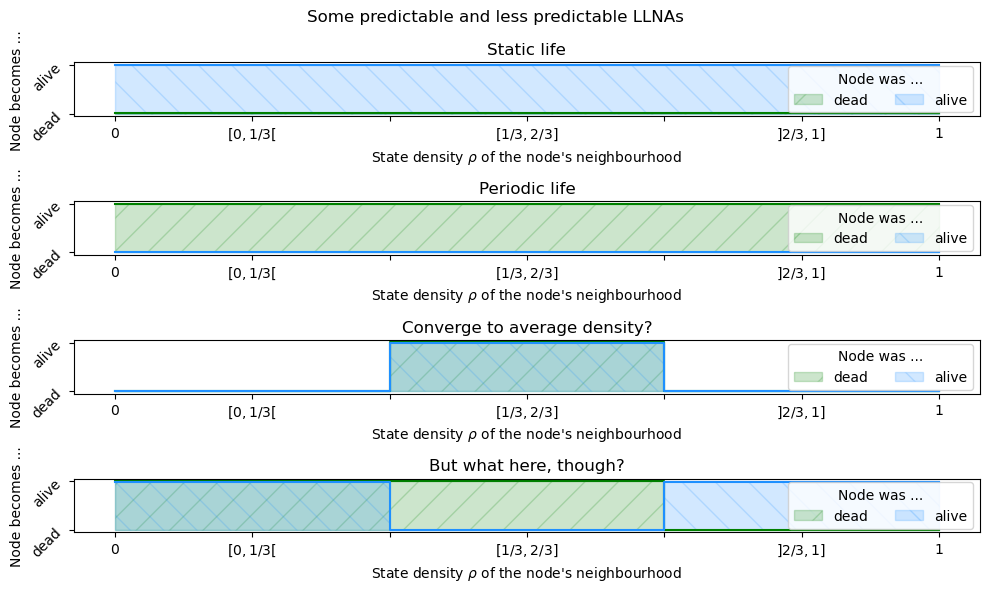

In [3]:
# verify for some obvious cases: minimum

resolution = 3
fig, axs = plt.subplots(4,1,figsize=(10,6))

# assign rules and generate LLNA
born_if = []
survive_if = [0, 1, 2]
model0 = LLNA(resolution, x=born_if, y=survive_if, iso=True)
model0.diagram(ax=axs[0])
axs[0].set_title(fr"Static life")

# assign rules and generate LLNA
born_if = [0, 1, 2]
survive_if = []
model1 = LLNA(resolution, x=born_if, y=survive_if, iso=True)
model1.diagram(ax=axs[1])
axs[1].set_title(fr"Periodic life")

# assign rules and generate LLNA
born_if = [1]
survive_if = [1]
model2 = LLNA(resolution, x=born_if, y=survive_if, iso=True)
model2.diagram(ax=axs[2])
axs[2].set_title(fr"Converge to average density?")

# assign rules and generate LLNA
born_if = [0,1]
survive_if = [0,2]
model3 = LLNA(resolution, x=born_if, y=survive_if, iso=True)
model3.diagram(ax=axs[3])
axs[3].set_title(fr"But what here, though?")

fig.suptitle(fr"Some predictable and less predictable LLNAs")
fig.tight_layout()

Let us see how this actually works out in a density time series on a ring network.

In [4]:
def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=float)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

100%|██████████| 9/9 [00:00<00:00, 21.95it/s]


Text(0.5, 1.0, 'Density evolutions from different initial densities')

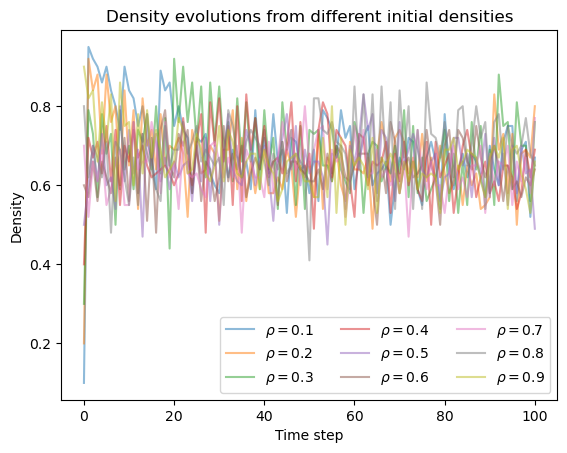

In [5]:
# show some density paths for a couple of initial conditions for a particular LLNA

N = 100
G = ig.Graph.Ring(N)
T = 100

# find edges
G.to_directed()
edges = tc.tensor(G.get_edgelist()).T
G.to_undirected()

# random init config
for init_rho in tqdm(np.arange(0.1,1,.1)):
    s0 = init_config_with_dens(N, init_rho)
    s0 = tc.tensor(s0)[None,:]

    # evolve first model
    s = model3.forward(edges, s0, T=T)
    s = np.array(s)[0]
    s_mean = np.mean(s, axis=1)

    plt.plot(s_mean, label=fr'$\rho={round(init_rho,1)}$', alpha=.5)
plt.legend(ncol=3)
plt.ylabel("Density")
plt.xlabel("Time step")
plt.title("Density evolutions from different initial densities")

We can understand this behaviour in a course-grained fashion by looking at the average densities.

- In an initial random configuration of exactly $N/2$ "alive" nodes, there is a probability of $50$ percent of encountering an alive node.
- If the network is sufficiently large, then approximately $50$ percent of the neighbouring cells will be alive
- More specifically, for a ring network, there is a $1/4$ probability of all of the neighbours being alive (dead), and a $1/2$ probability of half of the neighbours being alive (dead).
- If you're dead, a particular response is triggered. If the node is alive, another response is triggered.

For a random node with index $i$ with $2$ neighbours (in the ring network), therefore, the expectation value of its state evolves in a mean-field fashion as follows:
$$
\mathbb{E}(s_i^{t+1}) = \bar{\rho}^t \left( \dfrac{1}{4} S_0 + \dfrac{2}{4} S_1 + \dfrac{1}{4} S_2 \right) + (1-\bar{\rho}^t)\left( \dfrac{1}{4} B_0 + \dfrac{2}{4} B_1 + \dfrac{1}{4} B_2 \right),
$$
where $B_i$ (resp. $S_i$) is $1$ if a cell is born (reps. survives) if it has a density in interval $i$, and $0$ otherwise. The average density of the system at time $t$, $\bar{\rho}^t$ is taken to be equal to the average state of any given node, so $\mathbb{E}(s_i^t) = \bar{\rho}^t = \sum_{i=1}^N \rho_i^t$.

So, for $S_0 = S_2 = B_0 = B_2 = 0$ and $S_1 = B_1 = 1$, we find
$$
\bar{\rho}^{t+1} = \bar{\rho}^t \left(\dfrac{2}{4}\right) + (1-\bar{\rho}^t)\left(\dfrac{2}{4}\right) = 1/2,
$$
such that there is a 50/50 percent chance of finding a living node in the network.

This is in general not trivial, however, because the probabilities of encountering particular densities also changes over time:
$$
\bar{\rho}^{t+1} = \bar{\rho}^t \sum_{j=0}^{R-1}P(\rho^t \in R_j)S_j + (1-\bar{\rho}^t)\sum_{j=0}^{R-1}P(\rho^t \in R_j)B_j,
$$
or, more compactly
\begin{align}
\boxed{\bar{\rho}^{t+1} =  \sum_{j=0}^{R-1}P(\rho^t \in R_j)\left\{ \bar{\rho}^t S_j + (1-\bar{\rho}^t) B_j\right\}}
\end{align}
The factor $P(\rho^t \in R_j)$ represents the probability of encountering at time $t$ a local neighbourhood density $\rho^t$ that is in the density interval $R_j$, given an average network density of $\bar{\rho}^t$. Here the terms $B_j$ and $S_j$ are fixed by the local update rule, but the probabilities $P$ generally change over time. In particular, $P$ is a binomial distribution, with
$$
P(\rho^t \in R_j) = \binom{R-1}{j} (\bar{\rho}^t)^j (1-\bar{\rho}^t)^{R-j-1},
$$
where $R-1 = d=2$ is the degree (which is fixed to $2$ for ring networks), and $j \in \{0, 1, 2\}$. Note that for general networks, this probability depends on the (varying) node degree. Below some of these probabilities are shown.

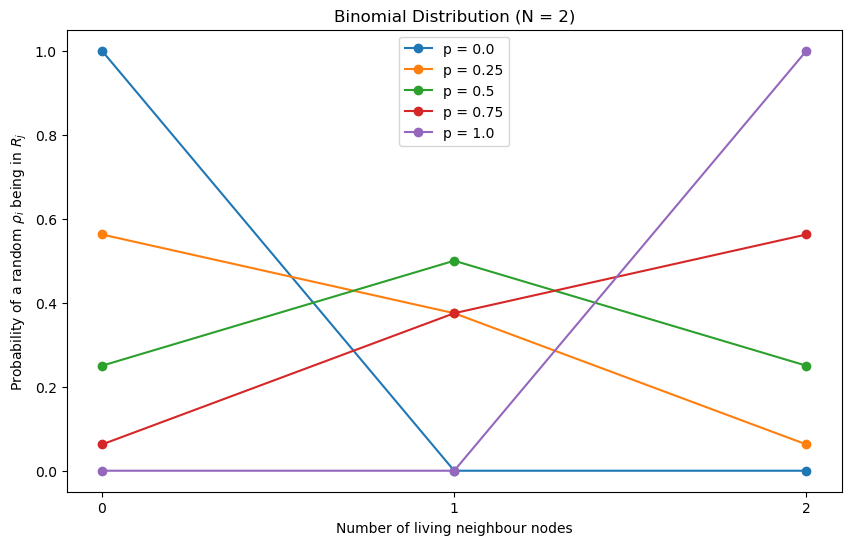

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom

def plot_binomial_distribution(N, p_values):
    x = np.arange(0, N + 1)  # Possible values of k (0 to N)
    plt.figure(figsize=(10, 6))

    for p in p_values:
        probabilities = binom.pmf(x, N, p)  # Compute binomial probabilities
        plt.plot(x, probabilities, marker='o', label=f'p = {p}')
    
    plt.title(f'Binomial Distribution (N = {N})')
    plt.xlabel('Number of living neighbour nodes')
    plt.xticks([0, 1, 2])
    plt.ylabel(fr'Probability of a random $\rho_i$ being in $R_j$')
    plt.legend()
    plt.show()

# Example usage:
N = 2  # Total number of boxes
p_values = np.linspace(0, 1, 5)  # Probabilities to check a single box
plot_binomial_distribution(N, p_values)


Below we show some randomly chosen LLNA

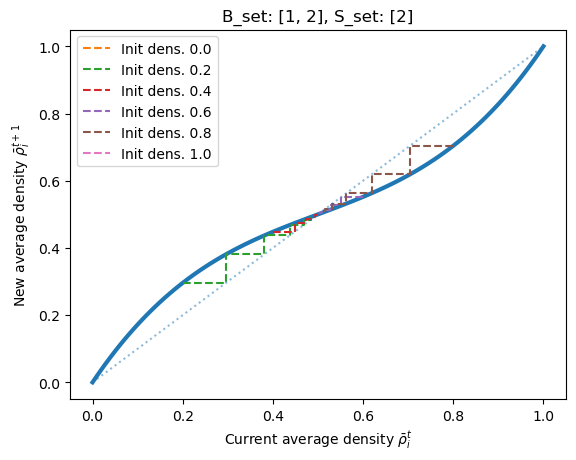

In [8]:
# code this recurrent behaviour

def mean_field_dens_propagation(dens, resolution, B_set, S_set):
    B_set_binary = np.zeros(resolution)
    S_set_binary = np.zeros(resolution)
    B_set_binary[B_set] = 1
    S_set_binary[S_set] = 1
    new_dens = 0
    for j in range(resolution):
        prob = binom.pmf(j, resolution-1, dens)
        update = dens * S_set_binary[j] + (1-dens) * B_set_binary[j]
        # make sure the density is between 0 and 1
        product = prob * update
        new_dens += product
    return np.clip(new_dens, 0, 1)

dens_list = np.linspace(0,1,101)
resolution = 3

import itertools
R_set = np.arange(resolution)
all_possible_subsets = list(itertools.chain.from_iterable(itertools.combinations(R_set, r) for r in range(resolution+1)))

B_set = list(all_possible_subsets[np.random.randint(2**resolution)])
S_set = list(all_possible_subsets[np.random.randint(2**resolution)])
new_dens_list = [mean_field_dens_propagation(dens, resolution, B_set, S_set) for dens in dens_list]

plt.plot(dens_list, new_dens_list, lw=3)
plt.title(f"B_set: {B_set}, S_set: {S_set}")
plt.xlabel(fr"Current average density $\bar{{\rho}}_i^t$")
plt.ylabel(fr"New average density $\bar{{\rho}}_i^{{t+1}}$")

def cobweb_list(init_dens, update_fun, T):
    # create two lists that can used to plot a cobweb plot
    # inputs are: initial density, the update function with a single numeric argument, and the number of time steps
    # Start list on the update curve
    dens_x_new = init_dens
    dens_y_new = update_fun(init_dens)
    dens_x_list = [dens_x_new]
    dens_y_list = [dens_y_new]
    for _ in range(T-1):
        # move to first bisector
        dens_x_list.append(dens_y_new)
        dens_y_list.append(dens_y_new)
        # update value according to update function
        dens_x_new = dens_y_new
        dens_y_new = update_fun(dens_y_new)
        # move to new point on update curve
        dens_x_list.append(dens_x_new)
        dens_y_list.append(dens_y_new)
    return dens_x_list, dens_y_list

from functools import partial
update_fun = partial(mean_field_dens_propagation, resolution=resolution, B_set=B_set, S_set=S_set)

init_dens = .5
T = 6
dens_x_list, dens_y_list = cobweb_list(init_dens, update_fun, T)

ddens = .2
for dens_init in np.arange(0, 1+ddens, ddens):
    dens_x_list, dens_y_list = cobweb_list(dens_init, update_fun, T)
    plt.plot(dens_x_list, dens_y_list, ls='--', label=f"Init dens. {round(dens_init,1)}")
plt.plot([0, 1], [0, 1], ls=':', color='tab:blue', alpha=.5)
plt.legend()
# plt.grid(True)

**Fixed points**

The analytical expression above allows us to identify fixed points of this system, as well as their stability. Note the following:
1. If the average density is fixed, we find that $\bar{\rho}^{t+1} = \bar{\rho}^t$. Let's call this $\bar{rho}^*$.
2. If this fixed point is stable, small perturbations should cancel out. If it is unstable, small perturbations will amplify. This translates to the following demands:
    - $\left|\dfrac{d\bar{\rho}^{t+1}}{d\bar{\rho}^{t}}\right|_{\bar{\rho}^t = \bar{\rho}^*} < 1$: stable fixed point
    - $\left|\dfrac{d\bar{\rho}^{t+1}}{d\bar{\rho}^{t}}\right|_{\bar{\rho}^t = \bar{\rho}^*} > 1$: unstable fixed point
    - $\left|\dfrac{d\bar{\rho}^{t+1}}{d\bar{\rho}^{t}}\right|_{\bar{\rho}^t = \bar{\rho}^*} = 1$: borderline stable fixed point
3. It is also possible to find closed loops (periodic mean-field behaviour), by demanding that $\bar{\rho}^{t+2} = \bar{\rho}^t \neq \bar{\rho}^{t+1}$ and using the recursive qualities of the expression.
4. This can be generalised to loops with a longer 'wavelength', but I presume the math becomes quite involved quite quickly.

Let us first find the general expression for the fixed point $\rho^*$.

\begin{align*}
\bar{\rho}^* =  \sum_{j=0}^{R-1}P(\rho \in R_j)\left\{ \bar{\rho}^* S_j + (1-\bar{\rho}^*) B_j\right\}, \qquad \qquad P(\rho \in R_j) = \binom{R-1}{j} (\bar{\rho}^*)^j (1-\bar{\rho}^*)^{R-j-1},
\end{align*}

so we want to solve
$$
\sum_{j=0}^{R-1}\binom{R-1}{j} (\bar{\rho}^*)^j (1-\bar{\rho}^*)^{R-j-1}\left\{ \bar{\rho}^* S_j + (1-\bar{\rho}^*) B_j\right\} = \bar{\rho}^*
$$
which may be re-written as
$$
\bar{\rho}^* \mathcal{S}(\bar{\rho}^*) + (1-\bar{\rho}^*)\mathcal{B}(\bar{\rho}^*) = \bar{\rho}^*
$$
with the truncated binomial sums
\begin{align}
\begin{cases}
    \mathcal{S}(\bar{\rho}^*) = \sum_{j=0}^{R-1}\binom{R-1}{j} (\bar{\rho}^*)^j (1-\bar{\rho}^*)^{R-j-1} S_j = \sum_{j:S_j=1}^{R-1}\binom{R-1}{j} (\bar{\rho}^*)^j (1-\bar{\rho}^*)^{R-j-1} \in [0, 1], \\
    \mathcal{B}(\bar{\rho}^*) = \sum_{j=0}^{R-1}\binom{R-1}{j} (\bar{\rho}^*)^j (1-\bar{\rho}^*)^{R-j-1} B_j = \sum_{j:B_j=1}^{R-1}\binom{R-1}{j} (\bar{\rho}^*)^j (1-\bar{\rho}^*)^{R-j-1} \in [0, 1].
\end{cases}
\end{align}
Depending on the values of the $S_j$ and $B_j$, this can become a difficult polynomial to solve for its real roots between $0$ and $1$. There are some special cases: if all density intervals are activated, the binomial sum is complete, such that $\mathcal{S}(\bar{\rho}^*) = 1$. If none are activated, the sum is zero. So:
- All survive, none are born: $\bar{\rho}^* = \bar{\rho}^*$: any initial density is a fixed point
- None survive, all are born: $\bar{\rho}^* = 0.5$: a density of 1/2 is a fixed point
- All survive, all are born: $\bar{\rho}^* = 1$: all nodes will become alive
- None surive, none are born: $\bar{\rho}^* = 0$: all nodes will die

We will find the solutions in a numerical way using `numpy`.

In [ ]:
import sympy as sp

# Define the variable and polynomial
rho = sp.symbols('rho')
S = sp.Function('S')
B = sp.Function('B')
expr = 1 - 3*x**2 + 3*x**3 - x

# 1-3p + 4p^2 - p^3

# Solve for roots
roots = sp.solve(expr, x)

# Evaluate roots numerically
numerical_roots = [root.evalf() for root in roots]

print("Symbolic roots:", roots)
print("Numerical roots:", numerical_roots)

Symbolic roots: [1, -sqrt(3)/3, sqrt(3)/3]
Numerical roots: [1.00000000000000, -0.577350269189626, 0.577350269189626]


In [89]:
from sympy import symbols, binomial, Sum, Piecewise, Or, Eq, solve, simplify, Interval

def find_fixed_points(resolution, B_set, S_set, eval=False):
    # TODO: I'm not sure whether this works well for resolution != 3
    # Define the symbols
    j = symbols('j', integer=True)
    rho = symbols('rho')

    # Explicitly compute the sums for S and B
    S_sum = sum(binomial(resolution - 1, j) * rho**j * (1 - rho)**(resolution - 1 - j) for j in S_set)
    B_sum = sum(binomial(resolution - 1, j) * rho**j * (1 - rho)**(resolution - 1 - j) for j in B_set)

    # fixed-point mean-field equation
    fixed_point_eq = Eq(rho*S_sum + (1-rho)*B_sum, rho)

    # find valid roots
    all_roots = solve(fixed_point_eq, rho)
    all_roots = [simplify(root) for root in all_roots]
    valid_roots = [root for root in all_roots if root.is_real and Interval(0, 1).contains(root)]
    if eval:
        return [valid_root.evalf() for valid_root in valid_roots]
    return valid_roots

resolution = 3
all_possible_subsets = list(itertools.chain.from_iterable(itertools.combinations(R_set, r) for r in range(resolution+1)))

for B_set in all_possible_subsets:
    for S_set in all_possible_subsets:
        print(B_set, S_set, find_fixed_points(resolution, B_set, S_set, eval=True))

() () [0]
() (0,) [0]
() (1,) [0]
() (2,) [0, 1.00000000000000]
() (0, 1) [0]
() (0, 2) [0, 1.00000000000000]
() (1, 2) [0, 1.00000000000000]
() (0, 1, 2) []
(0,) () [0.317672196171981]
(0,) (0,) [0.381966011250105]
(0,) (1,) [0.405585523983750]
(0,) (2,) [0.333333333333333, 1.00000000000000]
(0,) (0, 1) [0.500000000000000]
(0,) (0, 2) [1.00000000000000, 0.414213562373095]
(0,) (1, 2) [0.500000000000000, 1.00000000000000]
(0,) (0, 1, 2) [1.00000000000000]
(1,) () [0, 0.292893218813452]
(1,) (0,) [0, 0.422649730810374]
(1,) (1,) [0, 0.500000000000000]
(1,) (2,) [0, 0.333333333333333, 1.00000000000000]
(1,) (0, 1) [0, 0.585786437626905]
(1,) (0, 2) [0, 0.500000000000000, 1.00000000000000]
(1,) (1, 2) [0, 1.00000000000000]
(1,) (0, 1, 2) [0, 1.00000000000000]
(2,) () [0]
(2,) (0,) [0]
(2,) (1,) [0]
(2,) (2,) [0, 1.00000000000000]
(2,) (0, 1) [0, 0.500000000000000]
(2,) (0, 2) [0, 1.00000000000000]
(2,) (1, 2) [0, 0.500000000000000, 1.00000000000000]
(2,) (0, 1, 2) [0, 1.00000000000000]
(0

In [82]:
solve?

Signature: solve(f, *symbols, **flags)
Docstring:
Algebraically solves equations and systems of equations.

Explanation

Currently supported:
    - polynomial
    - transcendental
    - piecewise combinations of the above
    - systems of linear and polynomial equations
    - systems containing relational expressions
    - systems implied by undetermined coefficients

Examples

The default output varies according to the input and might
be a list (possibly empty), a dictionary, a list of
dictionaries or tuples, or an expression involving relationals.
For specifics regarding different forms of output that may appear, see :ref:`solve_output`.
Let it suffice here to say that to obtain a uniform output from
`solve` use ``dict=True`` or ``set=True`` (see below).

    >>> from sympy import solve, Poly, Eq, Matrix, Symbol
    >>> from sympy.abc import x, y, z, a, b

The expressions that are passed can be Expr, Equality, or Poly
classes (or lists of the same); a Matrix is considered to be a
lis

In [78]:
from sympy import symbols, binomial, Eq, solve, simplify

# Define the symbols
j = symbols('j', integer=True)
rho = symbols('rho')

# Parameters
R = 3
S_set = [2]  # Example values for S_j
B_set = [2]  # Example values for B_j

# Explicitly compute the sums for S and B
S_sum = sum(binomial(R - 1, j) * rho**j * (1 - rho)**(R - 1 - j) for j in S_set)
B_sum = sum(binomial(R - 1, j) * rho**j * (1 - rho)**(R - 1 - j) for j in B_set)

# Fixed-point mean-field equation
fixed_point_eq = Eq(rho * S_sum + (1 - rho) * B_sum, rho)

# Solve for rho
roots = solve(fixed_point_eq, rho)
roots = [simplify(root) for root in roots]  # Simplify the roots if needed

# Output the roots
print("Roots of the equation:")
print(roots)


Roots of the equation:
[0, 1]


8it [00:06,  1.23it/s]


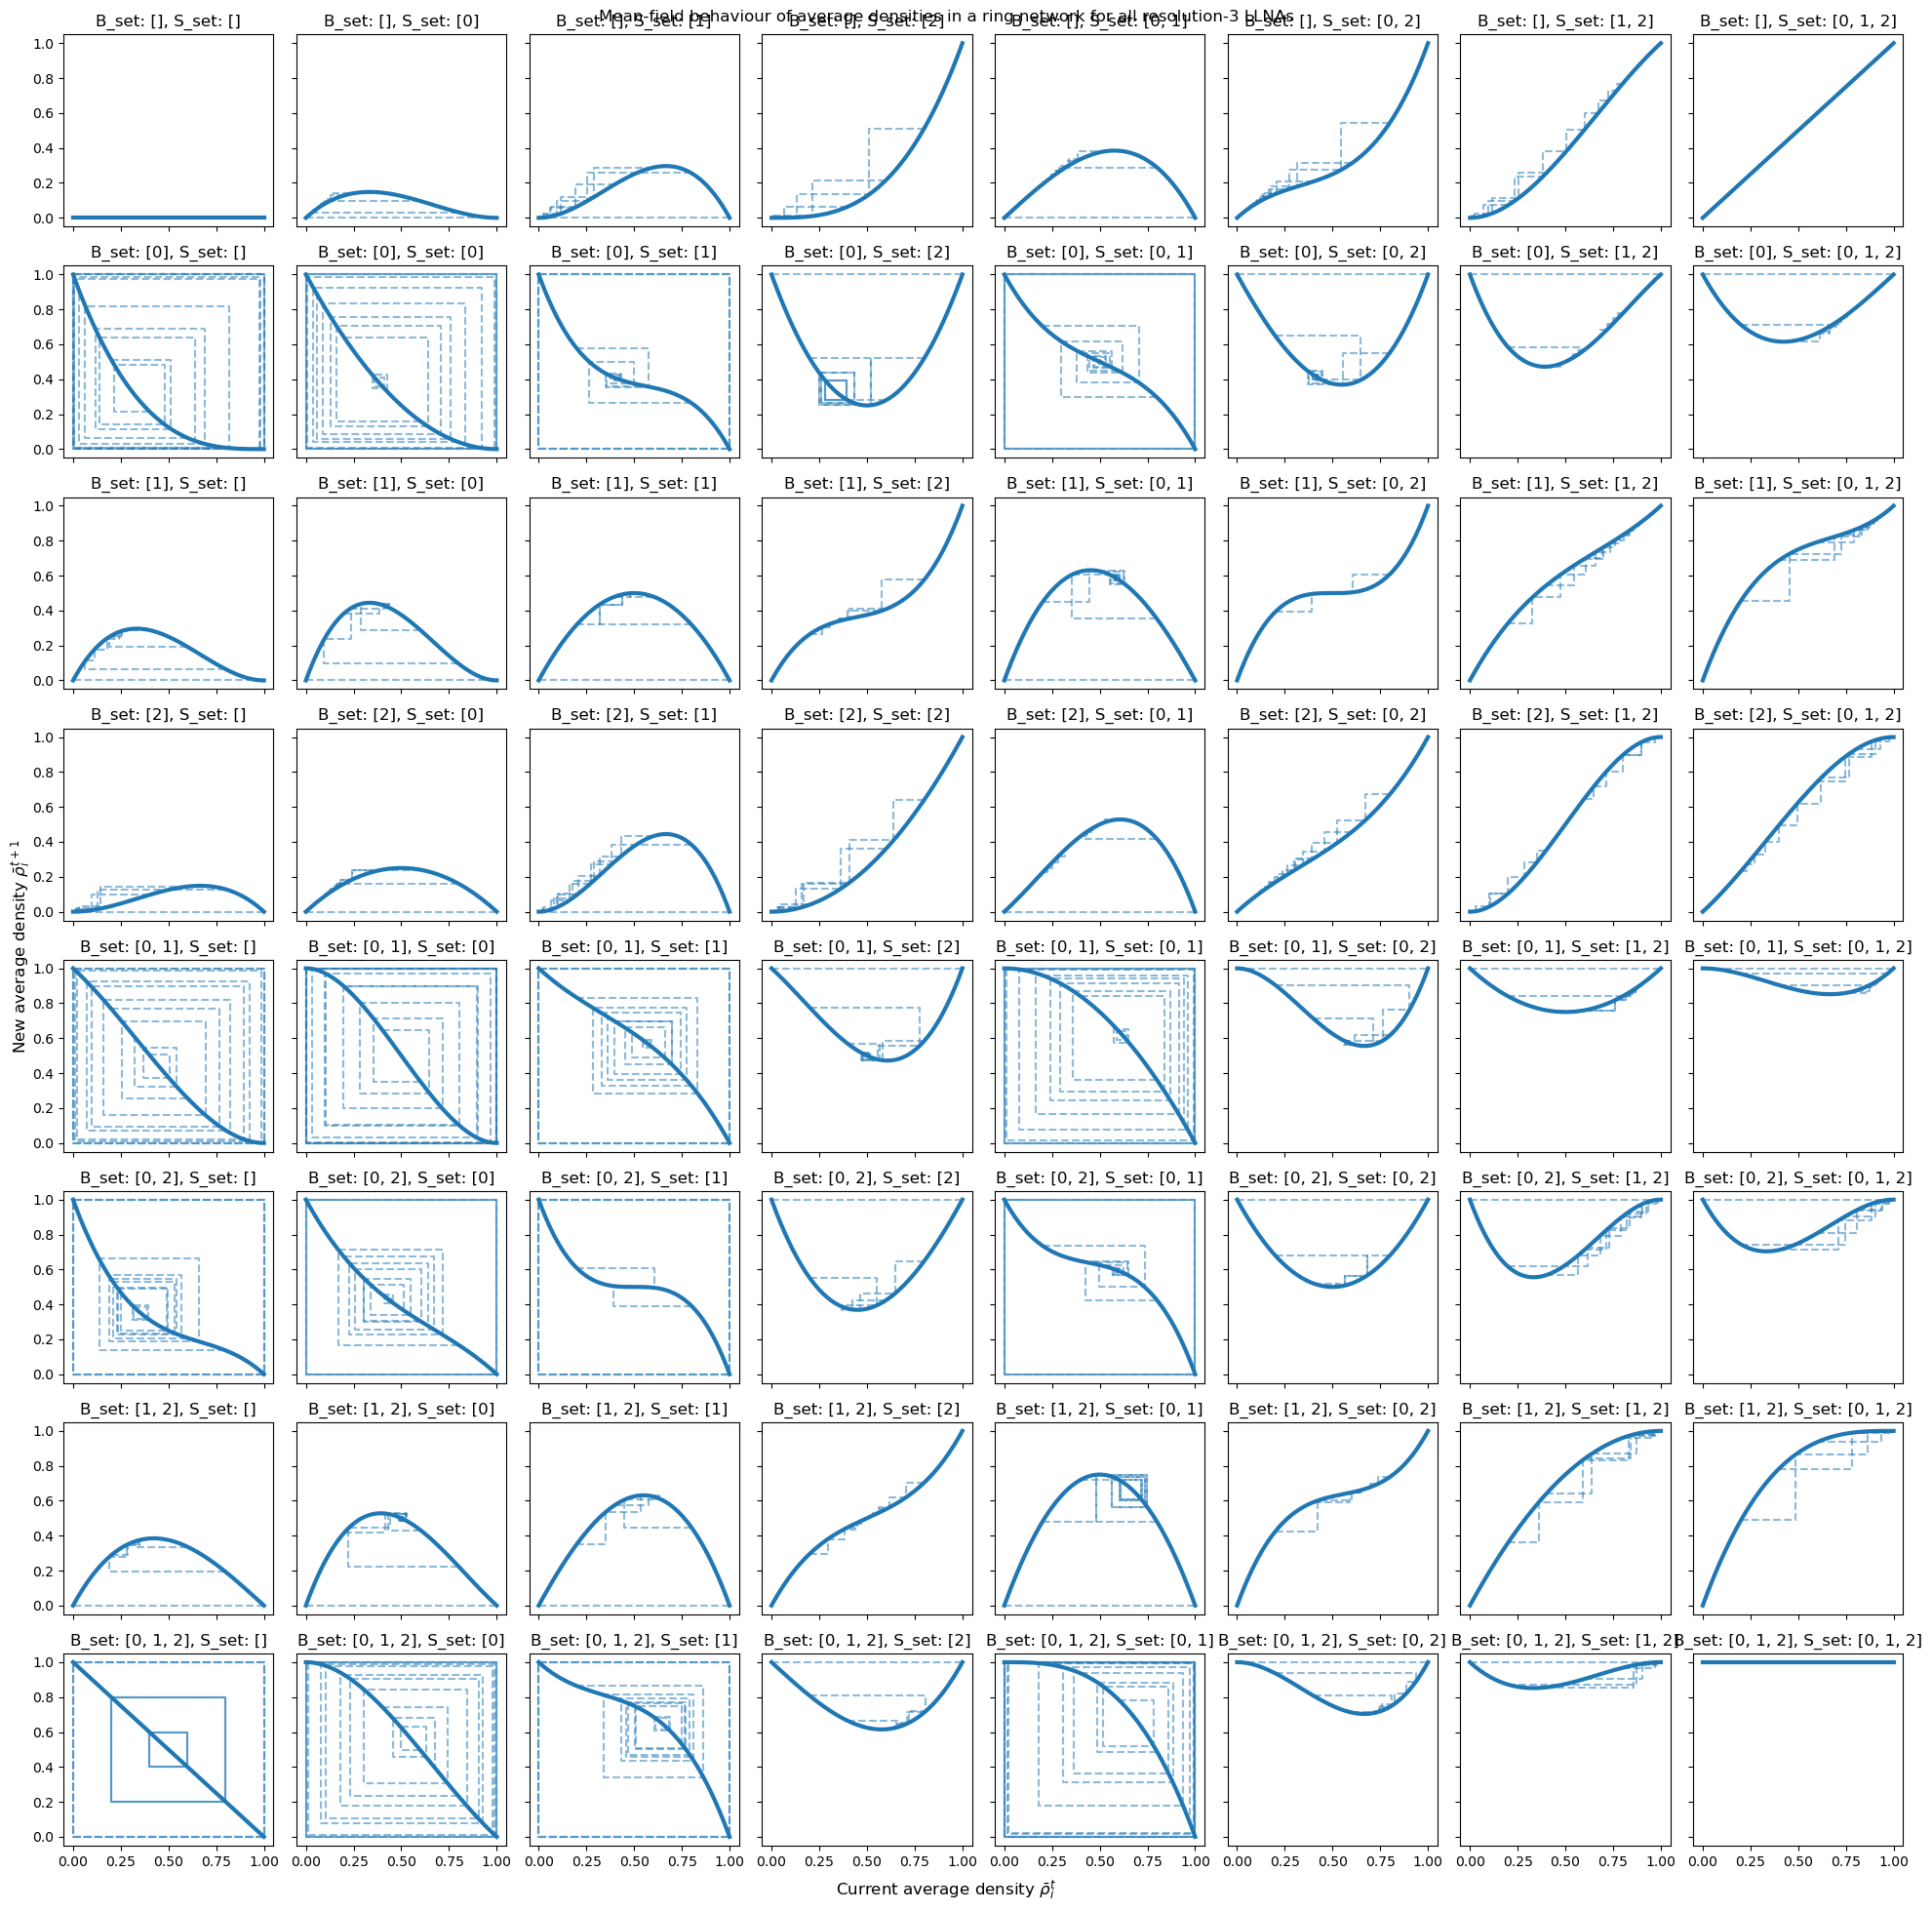

In [116]:
fig, axs = plt.subplots(8,8,figsize=(20,20), sharex=True, sharey=True)

dens_list = np.linspace(0,1,101)
resolution = 3

all_possible_subsets = list(chain.from_iterable(itertools.combinations(R_set, r) for r in range(resolution+1)))
for axh, B_set in tqdm(zip(axs, all_possible_subsets)):
    for ax, S_set in zip(axh, all_possible_subsets):
        new_dens_list = [mean_field_dens_propagation(dens, resolution, list(B_set), list(S_set)) for dens in dens_list]

        ax.plot(dens_list, new_dens_list, lw=3)
        ax.set_title(f"B_set: {list(B_set)}, S_set: {list(S_set)}")
        ax.set_xlim([-0.05,1.05])
        ax.set_ylim([-0.05,1.05])

        # plot some paths
        update_fun = partial(mean_field_dens_propagation, resolution=resolution, B_set=list(B_set), S_set=list(S_set))
        T = 5
        ddens = 0.2
        for dens_init in np.arange(0, 1+ddens, ddens):
            dens_x_list, dens_y_list = cobweb_list(dens_init, update_fun, T)
            ax.plot(dens_x_list, dens_y_list, ls='--', color='tab:blue', alpha=.5)

fig.suptitle("Mean-field behaviour of average densities in a ring network for all resolution-3 LLNAs")
fig.supxlabel(fr"Current average density $\bar{{\rho}}_i^t$")
fig.supylabel(fr"New average density $\bar{{\rho}}_i^{{t+1}}$")
fig.tight_layout()

To do next:
1. inspect some of these plots with actual paths from cellular automata
2. analytically find the stable points of these systems
3. find the isomorphic cases and compare their density curves

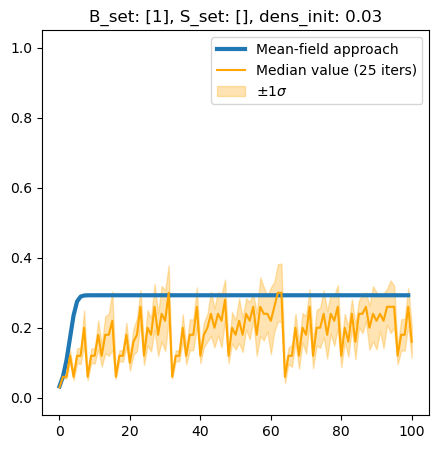

In [262]:
# code this recurrent behaviour
resolution = 3
dens_init = np.random.rand()
T = 100

import itertools
R_set = np.arange(resolution)
all_possible_subsets = list(chain.from_iterable(itertools.combinations(R_set, r) for r in range(resolution+1)))

B_set = list(all_possible_subsets[np.random.randint(2**resolution)])
S_set = list(all_possible_subsets[np.random.randint(2**resolution)])

update_fun = partial(mean_field_dens_propagation, resolution=resolution, B_set=B_set, S_set=S_set)
densities_over_time = cobweb_list(dens_init, update_fun, T)[0][::2]

fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.set_title(f"B_set: {list(B_set)}, S_set: {list(S_set)}, dens_init: {round(dens_init,2)}")
ax.plot(densities_over_time, lw=3, label="Mean-field approach")
ax.set_ylim([-0.05,1.05])

# plot actual densities from simulations
N = 100
G = ig.Graph.Ring(N)
# find edges
G.to_directed()
edges = tc.tensor(G.get_edgelist()).T
G.to_undirected()

# make model
model = LLNA(resolution, x=B_set, y=S_set, iso=True)

# make realisations from various initial conditions with identical initial density
iters = 25
rhos = []
for _ in range(iters):
    s0 = init_config_with_dens(N, dens_init)
    s0 = tc.tensor(s0)[None,:]

    # evolve first model
    s = model.forward(edges, s0, T=T)
    s = np.array(s)[0]
    rho = np.mean(s, axis=1)
    rhos.append(rho)

# plot on same ax
rhos = np.array(rhos)
ax.plot(np.median(rhos,axis=0), color='orange', label=f'Median value ({iters} iters)')
ax.fill_between(range(T+1), np.median(rhos,axis=0)-np.std(rhos,axis=0),
                np.median(rhos,axis=0)+np.std(rhos,axis=0),
                color='orange', alpha=.3, label=fr'$\pm 1\sigma$')

ax.legend()


In [218]:
densities_over_time

[0.6796781458293543,
 0.39006097134890005,
 0.755051702836916,
 0.2902511488698846,
 0.855960960911044,
 0.1617978706685307,
 0.9518785318956211,
 0.05032571008292193,
 0.9950621045825336,
 0.004962157828848739,
 0.9999508761626268,
 4.912625040606559e-05,
 0.9999999951733429,
 4.8266570973162545e-09,
 1.0000000000000013,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan]

In [114]:
# show some density paths for a couple of initial conditions for a particular LLNA


T = 100



# random init config
for init_rho in tqdm(np.arange(0.1,1,.1)):
    s0 = init_config_with_dens(N, init_rho)
    s0 = tc.tensor(s0)[None,:]

    # evolve first model
    s = model3.forward(edges, s0, T=T)
    s = np.array(s)[0]
    s_mean = np.mean(s, axis=1)

    plt.plot(s_mean, label=fr'$\rho={round(init_rho,1)}$', alpha=.5)
plt.legend(ncol=3)
plt.ylabel("Density")
plt.xlabel("Time step")
plt.title("Density evolutions from different initial densities")

[0.5,
 0.7500000000000002,
 0.4374999999999998,
 0.8085937500000004,
 0.34617614746093683,
 0.8801620749291039,
 0.22531472185649454,
 0.9492332761147302,
 0.0989561875164964,
 0.9902076729521997,
 0.01948876442658954,
 0.9996201880611248,
 0.000759479620641392,
 0.9999994231907054,
 1.1536182563913845e-06,
 0.9999999999986681,
 2.663869125283828e-12,
 1.0000000000000018,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan]